# Prediction of future volatility with VSIG

## Motivation

This notebook compares **predictive power** of different feature representations for **future realized volatility (RV)** forecasting on SPX (S&P 500) data. 

Given a historical window of **p past log-prices**, we aim to predict the realized volatility over the **next q days**, using Volterra signature features.

## Methodology

For each configuration (p, q, depth), we:

1. **Extract features** from the past p observations using three methods:
   - **Sig**: Classical path signatures (iisignature backend)
   - **HAR**: Realized Autoregression with fixed lag structure (1, 5, 22 days)
   - **VSig**: Volterra signatures with rank-2 FSSK kernels (tensordev backend)

2. **Train-validate-test pipeline**:
   - Chronological 80/20 split into training and test sets
   - Within training: further split into fit (60%) and validation (20%) with purging
   - Ridge regression over a tuned regularization grid
   - Cross-validated hyperparameter selection via **Optuna** (150 trials per setting)

3. **Hyperparameter optimization** for VSig:
   - **Rank-2 skew-symmetric coupling**: 
     $$\Lambda = \begin{pmatrix} \lambda_1 & c \\ -c & \lambda_2 \end{pmatrix}$$
   - Free parameters: λ₁, λ₂ ∈ [10, 80], α₁, α₂ ∈ [0.01, 30], c ∈ [-2, 2]
   - Search space: 150 trials per (depth, q) pair using TPE sampler

4. **Performance sweep** over p ∈ {10, 20, ..., 240}:
   - For each p, refit final Ridge model on all training data
   - Evaluate on validation and test sets using **R²** and **RMSE**
   - Compare trajectories: How does forecast accuracy degrade with larger p (older history)?

In [ ]:
%pip install tensordev

# Step 1: Wrappers for VSig computation

In [1]:
# ============================================================
# Updated JAX VSig config with skew off-diagonal coupling
# Lambda = [[lambda1, c], [-c, lambda2]]
# ============================================================
import jax
jax.config.update("jax_enable_x64", True)
from dataclasses import dataclass
from typing import Literal, Any

import numpy as np
import jax
import jax.numpy as jnp

from tensordev import FSSK
from tensordev import StateSpaceSignature


@dataclass(frozen=True)
class VSigJaxPastConfig:
    trunc: int
    lambdas: tuple[float, float]
    alphas: tuple[float, float]

    # New: skew-symmetric off-diagonal coupling
    # Lambda = [[lambda1, c], [-c, lambda2]]
    lambda_coupling: float = 0.0

    dt: float = 1.0
    input_transform: Literal[
        "logret_abs_time",
        "logret_abs",
        "return_abs_time",
    ] = "logret_abs_time"
    price_idx: int = 0
    include_level0: bool = False
    quad_order: int = 32
    dtype: Any = jnp.float64

    # If None, A = ones((1, path_dim, 2))
    A: Any = None

In [2]:
def _to_numpy(x) -> np.ndarray:
    """
    Accepts torch, numpy, or JAX arrays and returns a NumPy array.
    """
    # torch tensor
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()

    # JAX / NumPy
    return np.asarray(x)


def make_vsig_past_increments(
    x_past,
    *,
    dt: float = 1.0,
    input_transform: str = "legacy_logret_abs_time",
    price_idx: int = 0,
    dtype=jnp.float64,
):
    """
    Convert past log-price windows into increments for StateSpaceSignature.

    x_past: shape (N, p, d)

    Default legacy transform matches the old uncommented VSIG branch:
        r_i       = logS_{i+1} - logS_i
        abs_r_i   = |r_i|
        time_i    = i * dt

    Returns:
        X_inc: shape (N, p-1, m)
    """
    x = _to_numpy(x_past)

    if x.ndim != 3:
        raise ValueError(f"x_past must have shape (N,p,d), got {x.shape}")

    px = x[:, :, price_idx : price_idx + 1]

    if input_transform == "legacy_logret_abs_time":
        # Old uncommented VSIG branch:
        # r_i = logS_{i+1} - logS_i
        r = px[:, 1:, :] - px[:, :-1, :]
        abs_r = np.abs(r)
    
        L = r.shape[1]
        time_inc = np.arange(L, dtype=float).reshape(1, L, 1)
        time_inc = np.broadcast_to(time_inc, r.shape) * float(dt)
    
        X_inc = np.concatenate([r, abs_r, time_inc], axis=-1)
    
    elif input_transform == "legacy_price_return_abs_time":
        # Arithmetic scale-invariant return from log-prices:
        # r_i = (S_{i+1} - S_i) / S_i
        S_now = np.exp(px[:, :-1, :])
        S_next = np.exp(px[:, 1:, :])
    
        r = (S_next - S_now) / S_now
        abs_r = np.abs(r)
    
        L = r.shape[1]
        time_inc = np.arange(L, dtype=float).reshape(1, L, 1)
        time_inc = np.broadcast_to(time_inc, r.shape) * float(dt)
    
        X_inc = np.concatenate([r, abs_r, time_inc], axis=-1)
    
    elif input_transform == "price_return_abs_time":
        # Same arithmetic return, but cleaner constant time increment.
        S_now = np.exp(px[:, :-1, :])
        S_next = np.exp(px[:, 1:, :])
    
        r = (S_next - S_now) / S_now
        abs_r = np.abs(r)
        time_inc = np.ones_like(r) * float(dt)
    
        X_inc = np.concatenate([r, abs_r, time_inc], axis=-1)
    
    elif input_transform == "logret_abs_time":
        # Log-return with cleaner constant time increment.
        r = px[:, 1:, :] - px[:, :-1, :]
        abs_r = np.abs(r)
        time_inc = np.ones_like(r) * float(dt)
    
        X_inc = np.concatenate([r, abs_r, time_inc], axis=-1)
    
    elif input_transform == "logret_abs":
        r = px[:, 1:, :] - px[:, :-1, :]
        abs_r = np.abs(r)
    
        X_inc = np.concatenate([r, abs_r], axis=-1)
    
    else:
        raise ValueError(f"Unknown input_transform: {input_transform}")


    return jnp.asarray(X_inc, dtype=dtype)

In [3]:
def make_r2_skew_matrix_fssk(
    *,
    lambdas,
    alphas,
    lambda_coupling: float = 0.0,
    path_dim: int,
    A=None,
    quad_order: int = 32,
    dtype=jnp.float32,
) -> FSSK:
    """
    Build an R=2 finite-state-space kernel with

        Lambda = [[lambda1, c],
                  [-c,      lambda2]]

    Important convention:
        FSSK.from_matrix expects A with shape (q, m, path_dim).

    For signature-like features we want m = path_dim, hence the default

        A = identity(path_dim)

    so the output alphabet has the same dimension as the path.
    """
    lambdas_np = np.asarray(lambdas, dtype=float)
    alphas_np = np.asarray(alphas, dtype=float)

    if lambdas_np.shape != (2,):
        raise ValueError(f"Expected lambdas of shape (2,), got {lambdas_np.shape}")
    if alphas_np.shape != (2,):
        raise ValueError(f"Expected alphas of shape (2,), got {alphas_np.shape}")

    lam1, lam2 = float(lambdas_np[0]), float(lambdas_np[1])
    c = float(lambda_coupling)

    Lambda = jnp.asarray(
        [[lam1, c],
         [-c,  lam2]],
        dtype=dtype,
    )

    path_dim = int(path_dim)
    q = 1

    if A is None:
        # Correct default: m = path_dim, identity input map.
        # Shape: (q, m, path_dim)
        A_j = jnp.eye(path_dim, dtype=dtype)[None, :, :]
    else:
        A_np = np.asarray(A, dtype=float)

        # Allow A of shape (m, path_dim)
        if A_np.ndim == 2:
            A_np = A_np[None, :, :]

        if A_np.ndim != 3 or A_np.shape[0] != q or A_np.shape[2] != path_dim:
            raise ValueError(
                f"A must have shape (m, path_dim) or (1, m, path_dim), "
                f"got {A_np.shape}; expected trailing path_dim={path_dim}."
            )

        A_j = jnp.asarray(A_np, dtype=dtype)

    b = jnp.asarray(alphas_np.reshape(1, 2), dtype=dtype)

    kernel = FSSK.from_matrix(
        Lambda=Lambda,
        A=A_j,
        b=b,
        quad_order=int(quad_order),
    )

    if kernel.path_dim != path_dim:
        raise RuntimeError(
            f"Kernel path_dim={kernel.path_dim}, expected {path_dim}. "
            f"A_j.shape={A_j.shape}."
        )

    return kernel


def make_state_space_signature_from_config(
    cfg: VSigJaxPastConfig,
    *,
    path_dim: int,
) -> StateSpaceSignature:
    kernel = make_r2_skew_matrix_fssk(
        lambdas=cfg.lambdas,
        alphas=cfg.alphas,
        lambda_coupling=cfg.lambda_coupling,
        path_dim=path_dim,
        A=cfg.A,
        quad_order=cfg.quad_order,
        dtype=cfg.dtype,
    )

    return StateSpaceSignature(
        kernel=kernel,
        trunc=int(cfg.trunc),
    )

In [4]:
from functools import partial
import jax
import jax.numpy as jnp
import numpy as np


def flatten_dense_elem(sig, *, include_level0: bool = False):
    """
    Convert DenseElem returned by StateSpaceSignature.vsig into a flat matrix.

    Returns shape:
        (N, feature_dim)
    """
    levels = tuple(sig)

    if not include_level0:
        levels = levels[1:]

    if len(levels) == 0:
        raise ValueError("No signature levels left after removing level 0.")

    # infer batch size
    batch_size = None
    for z in levels:
        z = jnp.asarray(z)
        if z.ndim >= 1:
            batch_size = z.shape[0]
            break

    if batch_size is None:
        return jnp.concatenate([jnp.ravel(jnp.asarray(z)) for z in levels])[None, :]

    flat = []
    for z in levels:
        z = jnp.asarray(z)

        if z.ndim == 0:
            z = jnp.broadcast_to(z, (batch_size, 1))

        elif z.ndim == 1:
            if z.shape[0] == batch_size:
                z = z.reshape(batch_size, 1)
            else:
                z = jnp.broadcast_to(z.reshape(1, -1), (batch_size, z.shape[0]))

        else:
            z = z.reshape(batch_size, -1)

        flat.append(z)

    return jnp.concatenate(flat, axis=-1)


@partial(jax.jit, static_argnames=("include_level0",))
def _vsig_features_from_increments_jit(
    sss,
    X_inc,
    dt,
    *,
    include_level0: bool = False,
):
    sig = sss.vsig(
        X_inc,
        dt=dt,
        axis=-2,
        block_size=None,
        accumulate=True,
        output_starting_state=False,
        tau_dt=0.0,
        increment_input=True,
    )

    return flatten_dense_elem(sig, include_level0=include_level0)

In [5]:
def _vsig_features_from_increments_nojit(
    sss,
    X_inc,
    dt,
    *,
    include_level0: bool = False,
):
    sig = sss.vsig(
        X_inc,
        dt=dt,
        axis=-2,
        block_size=None,
        accumulate=True,
        output_starting_state=False,
        tau_dt=0.0,
        increment_input=True,
    )
    return flatten_dense_elem(sig, include_level0=include_level0)


def compute_vsig_features_jax_from_past(
    x_past,
    cfg: VSigJaxPastConfig,
    *,
    return_numpy: bool = True,
    use_jit: bool = False,
):
    X_inc = make_vsig_past_increments(
        x_past,
        dt=cfg.dt,
        input_transform=cfg.input_transform,
        price_idx=cfg.price_idx,
        dtype=cfg.dtype,
    )

    path_dim = int(X_inc.shape[-1])

    sss = make_state_space_signature_from_config(
        cfg,
        path_dim=path_dim,
    )

    if use_jit:
        Phi = _vsig_features_from_increments_jit(
            sss,
            X_inc,
            jnp.asarray(cfg.dt, dtype=cfg.dtype),
            include_level0=cfg.include_level0,
        )
    else:
        Phi = _vsig_features_from_increments_nojit(
            sss,
            X_inc,
            jnp.asarray(cfg.dt, dtype=cfg.dtype),
            include_level0=cfg.include_level0,
        )

    return np.asarray(Phi) if return_numpy else Phi

In [8]:
#classical signature using ii

# ============================================================
# Ordinary signature baseline matching the old "normal" branch
# ============================================================

import torch
from augmentations_ii import iisignature_sig

dt = 1.0

def compute_sig_past(
    x,
    p,
    mode="normal",
    N=None,
    add_time=True,
    sig_config_past=None,
):
    """
    Minimal version of the old compute_sig_past for ordinary signatures.

    Matches the old mode == "normal" branch:

        r_i = (S_{i+1} - S_i) / S_i
            = (exp(logS_{i+1}) - exp(logS_i)) / exp(logS_i)

        channels:
            r_i, |r_i|, time_i

        then prepend zero, take cumulative sum, and compute iisignature.
    """
    if sig_config_past is None:
        raise ValueError("sig_config_past must be provided.")

    if mode.lower() not in ("normal", "sig"):
        raise ValueError("This minimal compute_sig_past only supports mode='normal'/'SIG'.")

    if not torch.is_tensor(x):
        x = torch.as_tensor(x)

    sig_config_past.dt = 1.0
    dt_local = float(sig_config_past.dt)

    # x[:, :, 0] is log-price
    S_next = torch.exp(x[:, 1:, 0:1])
    S_now = torch.exp(x[:, :-1, 0:1])

    scale_invar_incr = (S_next - S_now) / S_now
    scale_invar_abs = scale_invar_incr.abs()

    L = scale_invar_incr.shape[1]

    t = torch.arange(
        L,
        device=scale_invar_incr.device,
        dtype=scale_invar_incr.dtype,
    ) * dt_local

    t = t.view(1, L, 1).expand(scale_invar_incr.shape[0], L, 1)

    x_new = torch.cat(
        [scale_invar_incr, scale_invar_abs, t],
        dim=-1,
    )

    # Add zero basepoint
    z = torch.zeros_like(x_new[:, :1, :])
    x_new = torch.cat([z, x_new], dim=1)

    # Cumulative path
    x_new_cum = x_new.cumsum(dim=1)

    return iisignature_sig(x_new_cum, sig_config_past)

In [9]:
def _ensure_windows(x, W_need: int, stride: int = 1):
    """
    Accepts:
      - x as (T,d) raw series -> returns (N,W_need,d)
      - x as (N,W,d) windows  -> returns x, or truncates to W_need if W>W_need

    Returns:
      torch tensor of shape (N,W_need,d)
    """
    if x is None:
        return None

    x = _as_torch(x)

    if x.ndim == 2:
        T, d = x.shape

        if T < W_need:
            raise ValueError(f"Need T >= W_need, got T={T}, W_need={W_need}")

        starts = range(0, T - W_need + 1, int(stride))
        return torch.stack([x[t:t + W_need] for t in starts], dim=0)

    if x.ndim == 3:
        N, W, d = x.shape

        if W < W_need:
            raise ValueError(f"Need W >= W_need, got W={W}, W_need={W_need}")

        if W == W_need:
            return x

        return x[:, :W_need, :]

    raise ValueError(f"x must have shape (T,d) or (N,W,d), got {tuple(x.shape)}")



# Step 2: Wrappers for prediciton

In [10]:
# ============================================================
# Prediction with JAX VSig features
# ============================================================

import numpy as np
import torch

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score


def make_future_target(
    x_future,
    *,
    target: str = "last",
    logvol_idx: int = -1,
):
    """
    x_future: shape (N, q, d)

    target="last":
        y = x_future[:, -1, logvol_idx]

    target="mean":
        y = mean over the q future values

    target="log_mean_square":
        y = log mean exp(2*x_future), useful if x_future is log-vol.
    """
    if not torch.is_tensor(x_future):
        x_future = torch.as_tensor(x_future)

    z = x_future[:, :, logvol_idx]

    if target == "last":
        y = z[:, -1]

    elif target == "mean":
        y = z.mean(dim=1)

    elif target == "log_mean_square":
        q = z.shape[1]
        y = torch.logsumexp(2.0 * z, dim=1) - torch.log(
            torch.tensor(float(q), device=z.device, dtype=z.dtype)
        )

    else:
        raise ValueError(f"Unknown target: {target}")

    return y.unsqueeze(-1)


def make_ridge_model(alpha: float):
    return make_pipeline(
        StandardScaler(),
        Ridge(alpha=float(alpha), fit_intercept=True),
    )


def fit_and_predict_2d(model, X_fit, Y_fit, X_pred):
    """
    Small sklearn shape helper.
    """
    if Y_fit.ndim == 2 and Y_fit.shape[1] == 1:
        model.fit(X_fit, Y_fit.ravel())
        pred = model.predict(X_pred).reshape(-1, 1)
    else:
        model.fit(X_fit, Y_fit)
        pred = model.predict(X_pred)
        if pred.ndim == 1:
            pred = pred.reshape(-1, 1)
    return pred


def metrics_1d(y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    err = y_true - y_pred
    mse = float(np.mean(err ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(err)))

    ss_res = float(np.sum(err ** 2))
    ss_tot = float(np.sum((y_true - np.mean(y_true)) ** 2))
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    return {
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }

In [11]:
# ============================================================
# Basic windowing helpers needed by fit_prediction_window_jax
# ============================================================

import torch
import numpy as np


def _as_torch(x, device=None, dtype=None):
    """
    Convert numpy/JAX/torch array to torch tensor.
    """
    if torch.is_tensor(x):
        out = x
    else:
        out = torch.as_tensor(np.asarray(x))

    if device is not None:
        out = out.to(device)

    if dtype is not None:
        out = out.to(dtype=dtype)

    return out


def _ensure_windows(x, W_need: int, stride: int = 1):
    """
    Accepts:
      - x as (T,d) raw series -> returns (N,W_need,d)
      - x as (N,W,d) windows  -> returns x or truncates to W_need

    Returns:
      torch tensor of shape (N,W_need,d)
    """
    if x is None:
        return None

    x = _as_torch(x)

    if x.ndim == 2:
        T, d = x.shape

        if T < W_need:
            raise ValueError(f"Need T >= W_need, got T={T}, W_need={W_need}")

        starts = range(0, T - W_need + 1, stride)
        return torch.stack([x[t:t + W_need] for t in starts], dim=0)

    if x.ndim == 3:
        N, W, d = x.shape

        if W < W_need:
            raise ValueError(f"Need W >= W_need, got W={W}, W_need={W_need}")

        if W == W_need:
            return x

        return x[:, :W_need, :]

    raise ValueError(f"x must have shape (T,d) or (N,W,d), got {tuple(x.shape)}")


def _split_past_future(x_real, p: int, q: int):
    """
    x_real: (N, W, d)

    Returns:
      x_past   : (N, p, d)
      x_future : (N, q, d)
    """
    if x_real.ndim != 3:
        raise ValueError(f"x_real must be (N,W,d), got shape {tuple(x_real.shape)}")

    N, W, d = x_real.shape

    if W < p + q:
        raise ValueError(f"Need W >= p+q, got W={W}, p={p}, q={q}")

    x_past = x_real[:, :p, :]
    x_future = x_real[:, p:p + q, :]

    return x_past, x_future

In [12]:
def _har_features_from_logvol_windows(
    x_past: torch.Tensor,
    logvol_idx: int = -1,
    lags=(1, 5, 22),
) -> torch.Tensor:
    """
    HAR-style trailing averages from the volatility/log-volatility channel.

    x_past: (N,p,d)
    output: (N,len(lags))
    """
    x_past = _as_torch(x_past)

    if x_past.ndim != 3:
        raise ValueError(f"x_past must have shape (N,p,d), got {tuple(x_past.shape)}")

    z = x_past[:, :, logvol_idx]

    feats = []
    for k in lags:
        kk = min(int(k), x_past.shape[1])
        feats.append(z[:, -kk:].mean(dim=1, keepdim=True))

    return torch.cat(feats, dim=1)

In [13]:
#the main prediction function for fixed parameters
def fit_prediction_window_jax(
    *,
    x_real_train,
    p: int,
    q: int,
    mode: str = "VSIG",
    x_real_test=None,

    # VSig/JAX parameters
    trunc: int = 3,
    lambdas=(10.0, 0.5),
    alphas=(1.0, 1.0),
    lambda_offdiag=0.0,
    dt: float = 1.0,
    input_transform: str = "logret_abs_time",
    include_level0: bool = False,
    quad_order: int = 32,

    # target
    target: str = "last",
    logvol_idx: int = -1,

    # HAR
    har_lags=(1, 5, 22),

    # validation/regression
    ridge_grid=(1e-8, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
    val_frac: float = 0.2,
    purge: int = 0,
    stride: int = 1,
    select: str = "mse",

    # optional old normal signature baseline
    sig_config_past=None,
):
    """
    Clean prediction routine.

    It handles:
        mode="VSIG"   -> JAX Volterra signature
        mode="HAR"    -> HAR features
        mode="normal" or "SIG" -> old iisignature baseline, if sig_config_past is provided
    """

    mode_upper = mode.upper()

    # -------------------------
    # windowing
    # -------------------------
    x_real_train = _as_torch(x_real_train)
    device = x_real_train.device
    out_dtype = x_real_train.dtype

    W_need = int(p) + int(q)

    x_train_w = _ensure_windows(x_real_train, W_need, stride=stride)
    x_past_tr, x_future_tr = _split_past_future(x_train_w, p, q)

    if x_real_test is not None:
        x_real_test = _as_torch(x_real_test, device=device)
        x_test_w = _ensure_windows(x_real_test, W_need, stride=stride)
        x_past_te, x_future_te = _split_past_future(x_test_w, p, q)
    else:
        x_past_te, x_future_te = None, None

    # -------------------------
    # target
    # -------------------------
    with torch.no_grad():
        Y_tr_t = make_future_target(
            x_future_tr,
            target=target,
            logvol_idx=logvol_idx,
        )

    Y_tr = Y_tr_t.detach().cpu().double().numpy()

    # -------------------------
    # feature computation
    # -------------------------
    def compute_X(x_past):
        if mode_upper == "HAR":
            X_t = _har_features_from_logvol_windows(
                x_past,
                logvol_idx=logvol_idx,
                lags=har_lags,
            )
            return X_t.detach().cpu().double().numpy()

        if mode_upper in ("NORMAL", "SIG"):
            if sig_config_past is None:
                raise ValueError("mode='normal'/'SIG' requires sig_config_past.")
            X_t = compute_sig_past(
                x_past,
                p,
                mode="normal",
                sig_config_past=sig_config_past,
            )
            return X_t.detach().cpu().double().numpy()

        if mode_upper == "VSIG":
            cfg = VSigJaxPastConfig(
                trunc=int(trunc),
                lambdas=tuple(float(x) for x in lambdas),
                alphas=tuple(float(x) for x in alphas),
                lambda_coupling=float(lambda_offdiag),   # keeps old function argument name
                dt=float(dt),
                input_transform=input_transform,
                price_idx=0,
                include_level0=bool(include_level0),
                quad_order=int(quad_order),
            )

            return compute_vsig_features_jax_from_past(
                x_past,
                cfg,
                return_numpy=True,
            ).astype(np.float64)

        raise ValueError(f"Unknown mode: {mode}")

    X_all = compute_X(x_past_tr)

    # -------------------------
    # chronological validation split
    # -------------------------
    N = X_all.shape[0]
    if N < 5:
        raise ValueError(f"Too few windows: N={N}")

    n_val = int(round(val_frac * N))
    n_val = max(1, min(n_val, N - 2))

    split = N - n_val

    fit_end = max(1, split - int(purge))
    if fit_end >= split:
        fit_end = max(1, split - 1)

    fit_idx = np.arange(0, fit_end)
    val_idx = np.arange(split, N)

    X_fit, Y_fit = X_all[fit_idx], Y_tr[fit_idx]
    X_val, Y_val = X_all[val_idx], Y_tr[val_idx]

    # -------------------------
    # tune Ridge alpha
    # -------------------------
    best_score = None
    best_ridge_alpha = None
    best_val_metrics = None

    def is_better(score, best):
        if best is None:
            return True
        if select == "r2":
            return score > best
        return score < best

    for ridge_alpha in ridge_grid:
        lm_tmp = make_ridge_model(ridge_alpha)
        Y_hat_val = fit_and_predict_2d(lm_tmp, X_fit, Y_fit, X_val)
        met = metrics_1d(Y_val, Y_hat_val)

        score = met["r2"] if select == "r2" else met["mse"]

        if is_better(score, best_score):
            best_score = score
            best_ridge_alpha = float(ridge_alpha)
            best_val_metrics = met

    # -------------------------
    # refit on full train
    # -------------------------
    lm = make_ridge_model(best_ridge_alpha)
    Y_hat_tr = fit_and_predict_2d(lm, X_all, Y_tr, X_all)
    train_metrics = metrics_1d(Y_tr, Y_hat_tr)

    result = {
        "mode": mode,
        "p": int(p),
        "q": int(q),
        "trunc": int(trunc),
        "lambdas": tuple(float(x) for x in lambdas) if mode_upper == "VSIG" else None,
        "alphas": tuple(float(x) for x in alphas) if mode_upper == "VSIG" else None,
        "lambda_offdiag": lambda_offdiag if mode_upper == "VSIG" else None,
        "input_transform": input_transform if mode_upper == "VSIG" else None,
        "best_ridge_alpha": best_ridge_alpha,
        "val": {
            "metrics": best_val_metrics,
            "n_fit": int(len(fit_idx)),
            "n_val": int(len(val_idx)),
            "purge": int(purge),
        },
        "train": {
            "metrics": train_metrics,
            "y_true": Y_tr,
            "y_pred": Y_hat_tr,
            "features": X_all,
        },
        "lm": lm,
    }

    # -------------------------
    # test evaluation
    # -------------------------
    if x_past_te is not None:
        with torch.no_grad():
            Y_te_t = make_future_target(
                x_future_te,
                target=target,
                logvol_idx=logvol_idx,
            )

        Y_te = Y_te_t.detach().cpu().double().numpy()
        X_te = compute_X(x_past_te)

        Y_hat_te = lm.predict(X_te)
        if Y_hat_te.ndim == 1:
            Y_hat_te = Y_hat_te.reshape(-1, 1)

        test_metrics = metrics_1d(Y_te, Y_hat_te)

        result["test"] = {
            "metrics": test_metrics,
            "y_true": Y_te,
            "y_pred": Y_hat_te,
            "features": X_te,
        }

    return result

In [21]:
pip install ccxt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.4/145.4 kB 974.3 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 3.9 MB/s eta 0:00:00
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 4.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 8.5 MB/s eta 0:00:0000:01:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.3/500.3 kB 8.6 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 10.3 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.3/86.3 kB 8.2 MB/s eta 0:00:00
Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl (15 kB)
Using cached aiosignal-1.4.0-py3-none-any.whl (7.5 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.0/181.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 5.8 MB/s 

In [ ]:
%pip install pandas
%pip install torch
%pip install tqdm
%pip install ccxt

# Step 3: Load data and test prediction

In [23]:
from data import get_data
p= 3
q=3
data = "SPX"
if data == "SPX":
    
    pipline, x_raw,x_real = get_data("STOCKS", p=p, q=q, assets=('SPX',), with_vol=True)
    x_real= x_raw[0]
    ind_train = int(x_real.shape[0] * 0.8)
    x_real_train, x_real_test = x_real[:ind_train,:], x_real[ind_train:,:]
elif data == "VIX":
    pipline, x_raw,x_real = get_data("SPXVIX", p=p, q=q, assets=("SPX", "VIX"), with_vol=True)
    x_real= x_raw[0]
    ind_train = int(x_real.shape[0] * 0.8)
    x_real_train, x_real_test = x_real[:ind_train,:], x_real[ind_train:,:]
elif data == "crypto":
    pip, x_raw, x_real = get_data(
        "CRYPTO", p, q,
        assets=("BTC", "ETH"),
        quote="USDT",
        timeframe="1h",
        start_iso="2020-01-01T00:00:00Z",
        end_iso="2025-01-01T00:00:00Z",
        with_vol=False,
        exchange_id="binance",
        
    )
    ind_train = int(x_real.shape[0] * 0.5)
    x_real_train, x_real_test = x_real[:ind_train,:], x_real[ind_train:,:]
elif data == "synthetic":
    from Sampling_models import fBm_sampling
    M= 2
    N=10000
    H=0.1
    fbm,dfBm,dW = fBm_sampling(M, N, H)
    W = np.zeros((N+1))
    W[1:] = np.cumsum(dW[0,:])
    x_real = np.zeros((N+1,2))
    x_real[:,0]= fbm[0,:]
    x_real[:,1] = W
    ind_train = int(x_real.shape[0] * 0.7)
    x_real_train, x_real_test = x_real[:ind_train,:], x_real[ind_train:,:]

elif data == "electricity":
    pipeline, x_raw, x = get_data(
    "ELECTRICITY_OPSD",
    p=48, q=24,
    path="time_series_60min_singleindex.csv",
    outputs=(
        "AT_price_day_ahead",
        "AT_load_actual_entsoe_transparency",
        "AT_wind_onshore_generation_actual",
        "AT_solar_generation_actual",
    ),
    scale="standard",
    dropna_outputs=True,
    price_col="AT_price_day_ahead",
    price_min=-500,
    price_max=5000,
    )
   
    x_real = np.zeros((x.shape[0],2))
    x_real[:,0] = x[:,0]
    x_real[:,1] = x[:,1]-x[:,2]-x[:,3]
    #x_real[:,1] = x[:,1]
    ind_train = int(x_real.shape[0] * 0.6)
    x_real_train, x_real_test = x_real[:ind_train,:], x_real[ind_train:,:]
elif data =="FRED":
    pipeline, x_raw, x_real = get_data(
    "FRED", p=0, q=0,
    start="2009-01-01",
    series_ids=("OVXCLS","VIXCLS","GVZCLS"),   # crude-oil, equity, gold implied vol
    outputs=("OVXCLS","VIXCLS","GVZCLS"),
    scale="standard",
    transform="log",
    fill="ffill",
    )
    print(x_real.shape)
    ind_train = int(x_real.shape[0] * 0.8)
    x_real_train, x_real_test = x_raw[0,:ind_train,1:3], x_raw[0,ind_train:,1:3]
    

(129209, 20)


# Step 3: Hyperparameter search using Optuna

In [26]:
# ============================================================
# JAX VSig SPX prediction: Optuna tuning + final p-sweep
# Assumes your VSig wrappers are already defined and stable:
#   - VSigJaxPastConfig
#   - make_vsig_past_increments
#   - make_state_space_signature_from_config
#   - compute_vsig_features_jax_from_past  with use_jit=False default
#   - fit_prediction_window_jax
# ============================================================

import os
import gc
import json
import pickle
from pathlib import Path

import optuna
import numpy as np
import pandas as pd

import jax

from augmentations_ii import SignatureConfig

try:
    from jax.errors import JaxRuntimeError
except Exception:
    JaxRuntimeError = RuntimeError


# ============================================================
# CLEANUP
# ============================================================

try:
    jax.clear_caches()
except Exception:
    pass

gc.collect()


# ============================================================
# OUTPUT FOLDER
# ============================================================

RESULTS_DIR = Path("SPX_pred_results")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# USER SETTINGS
# ============================================================

VSIG_MODE = "2L2A_COUPLED_FREEC"

RUN_SIG = True
RUN_HAR = True
RUN_VSIG = True

depth_list = [1, 2, 3, 4]
q_list = [1, 3, 5]

n_trials = 150
n_jobs = 4

dt = 1.0

p_list = [10 * j for j in range(1, 25)]
p_tune = int(max(p_list))

Kfolds = 3

# Uses log-price input, but computes arithmetic scale-invariant returns:
# r_i = (exp(logS_{i+1}) - exp(logS_i)) / exp(logS_i)
INPUT_TRANSFORM = "legacy_price_return_abs_time"

TARGET = "last"
LOGVOL_IDX = -1

SELECT = "mse"
VAL_FRAC = 0.2
PURGE = 0

RIDGE_GRID = (
    1e-8, 1e-6, 1e-5, 1e-4, 1e-3,
    1e-2, 1e-1, 1.0, 10.0, 100.0
)

SAVE_FEATURES_IN_DETAILS = False


# ============================================================
# PARAMETER RANGES
# ============================================================

LAM1_MIN, LAM1_MAX = 10.0, 80.0
LAM2_MIN, LAM2_MAX = 0.01, 33.0

A1_MIN, A1_MAX = 1e-2, 30.0
A2_MIN, A2_MAX = 1e-2, 30.0

# Free coupling:
# Lambda = [[lambda1, c],
#           [-c,      lambda2]]
C_MIN, C_MAX = -2.0, 2.0


# ============================================================
# HELPERS
# ============================================================

def make_sig_config(depth: int):
    return SignatureConfig(
        depth=int(depth),
        basepoint=True,
        dt=float(dt),
        lambd=1.0,
        alpha=1.0,
        augmentations=(),
    )


def strip_heavy_arrays(out):
    """
    Remove large feature arrays before saving details.
    Keeps metrics and predictions.
    """
    if SAVE_FEATURES_IN_DETAILS:
        return out

    out = dict(out)

    for split in ["train", "val", "test"]:
        if split in out and isinstance(out[split], dict):
            out[split] = dict(out[split])
            out[split].pop("features", None)

    return out


def sample_vsig_params_2l2a_coupled(trial: optuna.Trial):
    """
    Sample R=2 coupled kernel parameters.

        Lambda = [[lam1, c],
                  [-c,  lam2]]

    We enforce lam1 >= lam2 and swap the associated alpha.
    """
    lam1 = trial.suggest_float("lam1", LAM1_MIN, LAM1_MAX, log=True)
    lam2 = trial.suggest_float("lam2", LAM2_MIN, LAM2_MAX, log=True)

    a1 = trial.suggest_float("a1", A1_MIN, A1_MAX, log=True)
    a2 = trial.suggest_float("a2", A2_MIN, A2_MAX, log=True)

    if lam1 < lam2:
        lam1, lam2 = lam2, lam1
        a1, a2 = a2, a1

    c = trial.suggest_float("c", C_MIN, C_MAX)

    return {
        "lam1": float(lam1),
        "lam2": float(lam2),
        "a1": float(a1),
        "a2": float(a2),
        "c": float(c),
    }


def fit_one_vsig_candidate(
    *,
    x_train_or_windows,
    p: int,
    q: int,
    depth: int,
    params: dict,
    x_real_test=None,
    verbose=False,
):
    out = fit_prediction_window_jax(
        x_real_train=x_train_or_windows,
        x_real_test=x_real_test,

        p=int(p),
        q=int(q),
        mode="VSIG",

        trunc=int(depth),
        lambdas=(params["lam1"], params["lam2"]),
        alphas=(params["a1"], params["a2"]),
        lambda_offdiag=params["c"],

        dt=float(dt),
        input_transform=INPUT_TRANSFORM,

        target=TARGET,
        logvol_idx=LOGVOL_IDX,

        ridge_grid=RIDGE_GRID,
        val_frac=VAL_FRAC,
        purge=PURGE,
        stride=1,
        select=SELECT,
    )

    if verbose:
        print(
            f"depth={depth} q={q} "
            f"lam=({params['lam1']:.4g},{params['lam2']:.4g}) "
            f"a=({params['a1']:.4g},{params['a2']:.4g}) "
            f"c={params['c']:.4g} "
            f"val_mse={out['val']['metrics']['mse']:.4g}"
        )

    return out


def sweep_over_p_compare_modes_jax(
    *,
    x_real_train,
    x_real_test,
    p_list,
    q: int,
    depth: int,
    best_params: dict,
):
    rows = []
    details = {}

    sig_cfg = make_sig_config(depth)

    for p_cur in p_list:
        p_cur = int(p_cur)
        print(f"  p={p_cur}")

        out_sig = None
        out_har = None
        out_vsig = None

        # -------------------------
        # Sig baseline
        # -------------------------
        if RUN_SIG:
            out_sig = fit_prediction_window_jax(
                x_real_train=x_real_train,
                x_real_test=x_real_test,

                p=p_cur,
                q=int(q),
                mode="SIG",

                sig_config_past=sig_cfg,

                target=TARGET,
                logvol_idx=LOGVOL_IDX,

                ridge_grid=RIDGE_GRID,
                val_frac=VAL_FRAC,
                purge=PURGE,
                stride=1,
                select=SELECT,
            )
            details[("SIG", p_cur)] = strip_heavy_arrays(out_sig)

        # -------------------------
        # HAR baseline
        # -------------------------
        if RUN_HAR:
            out_har = fit_prediction_window_jax(
                x_real_train=x_real_train,
                x_real_test=x_real_test,

                p=p_cur,
                q=int(q),
                mode="HAR",

                target=TARGET,
                logvol_idx=LOGVOL_IDX,

                ridge_grid=RIDGE_GRID,
                val_frac=VAL_FRAC,
                purge=PURGE,
                stride=1,
                select=SELECT,
            )
            details[("HAR", p_cur)] = strip_heavy_arrays(out_har)

        # -------------------------
        # JAX VSig
        # -------------------------
        if RUN_VSIG:
            out_vsig = fit_prediction_window_jax(
                x_real_train=x_real_train,
                x_real_test=x_real_test,

                p=p_cur,
                q=int(q),
                mode="VSIG",

                trunc=int(depth),
                lambdas=(best_params["lam1"], best_params["lam2"]),
                alphas=(best_params["a1"], best_params["a2"]),
                lambda_offdiag=best_params["c"],

                dt=float(dt),
                input_transform=INPUT_TRANSFORM,

                target=TARGET,
                logvol_idx=LOGVOL_IDX,

                ridge_grid=RIDGE_GRID,
                val_frac=VAL_FRAC,
                purge=PURGE,
                stride=1,
                select=SELECT,
            )
            details[("VSIG", p_cur)] = strip_heavy_arrays(out_vsig)

        row = {
            "p": p_cur,
            "q": int(q),
            "depth_past": int(depth),
            "vsig_mode": VSIG_MODE,
            "input_transform": INPUT_TRANSFORM,

            "vsig_best_lambda1": best_params["lam1"],
            "vsig_best_lambda2": best_params["lam2"],
            "vsig_best_alpha1": best_params["a1"],
            "vsig_best_alpha2": best_params["a2"],
            "vsig_best_c": best_params["c"],
        }

        if out_sig is not None:
            row.update({
                "sig_train_mse": out_sig["train"]["metrics"]["mse"],
                "sig_train_r2": out_sig["train"]["metrics"]["r2"],
                "sig_val_mse": out_sig["val"]["metrics"]["mse"],
                "sig_val_r2": out_sig["val"]["metrics"]["r2"],
                "sig_best_ridge_alpha": out_sig["best_ridge_alpha"],
            })

            if "test" in out_sig:
                row.update({
                    "sig_test_mse": out_sig["test"]["metrics"]["mse"],
                    "sig_test_r2": out_sig["test"]["metrics"]["r2"],
                    "sig_test_rmse": out_sig["test"]["metrics"]["rmse"],
                    "sig_test_mae": out_sig["test"]["metrics"]["mae"],
                })

        if out_har is not None:
            row.update({
                "har_train_mse": out_har["train"]["metrics"]["mse"],
                "har_train_r2": out_har["train"]["metrics"]["r2"],
                "har_val_mse": out_har["val"]["metrics"]["mse"],
                "har_val_r2": out_har["val"]["metrics"]["r2"],
                "har_best_ridge_alpha": out_har["best_ridge_alpha"],
            })

            if "test" in out_har:
                row.update({
                    "har_test_mse": out_har["test"]["metrics"]["mse"],
                    "har_test_r2": out_har["test"]["metrics"]["r2"],
                    "har_test_rmse": out_har["test"]["metrics"]["rmse"],
                    "har_test_mae": out_har["test"]["metrics"]["mae"],
                })

        if out_vsig is not None:
            row.update({
                "vsig_train_mse": out_vsig["train"]["metrics"]["mse"],
                "vsig_train_r2": out_vsig["train"]["metrics"]["r2"],
                "vsig_val_mse": out_vsig["val"]["metrics"]["mse"],
                "vsig_val_r2": out_vsig["val"]["metrics"]["r2"],
                "vsig_best_ridge_alpha": out_vsig["best_ridge_alpha"],
            })

            if "test" in out_vsig:
                row.update({
                    "vsig_test_mse": out_vsig["test"]["metrics"]["mse"],
                    "vsig_test_r2": out_vsig["test"]["metrics"]["r2"],
                    "vsig_test_rmse": out_vsig["test"]["metrics"]["rmse"],
                    "vsig_test_mae": out_vsig["test"]["metrics"]["mae"],
                })

        rows.append(row)

    df = pd.DataFrame(rows).sort_values("p").reset_index(drop=True)
    return df, details


# ============================================================
# PRECOMPUTE WINDOWS PER q FOR OPTUNA
# ============================================================

x_w_by_q = {}
cuts_by_q = {}

for q_ in q_list:
    q_ = int(q_)
    W_need = p_tune + q_

    x_w = _ensure_windows(_as_torch(x_real_train), W_need, stride=1)
    Nw = int(x_w.shape[0])

    if Nw < 50:
        raise ValueError(
            f"Not enough windows for q={q_}: Nw={Nw}. "
            "Reduce p_tune/q or check data length."
        )

    cuts = np.linspace(int(0.55 * Nw), int(0.95 * Nw), Kfolds).astype(int)

    x_w_by_q[q_] = x_w
    cuts_by_q[q_] = cuts

    print(f"q={q_}: windows={Nw}, cuts={cuts.tolist()}")


# ============================================================
# SAVE RUN CONFIG
# ============================================================

run_config = {
    "VSIG_MODE": VSIG_MODE,
    "RUN_SIG": RUN_SIG,
    "RUN_HAR": RUN_HAR,
    "RUN_VSIG": RUN_VSIG,
    "depth_list": depth_list,
    "q_list": q_list,
    "n_trials": n_trials,
    "n_jobs": n_jobs,
    "dt": dt,
    "p_list": p_list,
    "p_tune": p_tune,
    "Kfolds": Kfolds,
    "INPUT_TRANSFORM": INPUT_TRANSFORM,
    "TARGET": TARGET,
    "LOGVOL_IDX": LOGVOL_IDX,
    "SELECT": SELECT,
    "VAL_FRAC": VAL_FRAC,
    "PURGE": PURGE,
    "RIDGE_GRID": RIDGE_GRID,
    "LAM1_MIN": LAM1_MIN,
    "LAM1_MAX": LAM1_MAX,
    "LAM2_MIN": LAM2_MIN,
    "LAM2_MAX": LAM2_MAX,
    "A1_MIN": A1_MIN,
    "A1_MAX": A1_MAX,
    "A2_MIN": A2_MIN,
    "A2_MAX": A2_MAX,
    "C_MIN": C_MIN,
    "C_MAX": C_MAX,
    "SAVE_FEATURES_IN_DETAILS": SAVE_FEATURES_IN_DETAILS,
}

with open(RESULTS_DIR / "run_config.json", "w") as f:
    json.dump(run_config, f, indent=2)


# ============================================================
# MAIN RUN
# ============================================================

all_trials_dfs = []
all_summary_dfs = []

all_results = {}
best_params_by_depth_q = {}


for depth_past in depth_list:
    depth_past = int(depth_past)

    for q_ in q_list:
        q_ = int(q_)

        print(f"\n===== DEPTH_PAST={depth_past} | q={q_} | {VSIG_MODE} =====")

        x_w_local = x_w_by_q[q_]
        cuts_local = cuts_by_q[q_]

        def objective(trial: optuna.Trial):
            params = sample_vsig_params_2l2a_coupled(trial)

            trial.set_user_attr("lam1_ordered", params["lam1"])
            trial.set_user_attr("lam2_ordered", params["lam2"])
            trial.set_user_attr("a1_ordered", params["a1"])
            trial.set_user_attr("a2_ordered", params["a2"])
            trial.set_user_attr("c", params["c"])

            mses = []
            r2s = []
            ridge_alphas = []

            for cut in cuts_local:
                try:
                    out = fit_one_vsig_candidate(
                        x_train_or_windows=x_w_local[:int(cut)],
                        p=p_tune,
                        q=q_,
                        depth=depth_past,
                        params=params,
                        x_real_test=None,
                        verbose=False,
                    )

                    val_mse = float(out["val"]["metrics"]["mse"])
                    val_r2 = float(out["val"]["metrics"].get("r2", np.nan))
                    ridge_alpha = float(out.get("best_ridge_alpha", np.nan))

                    if not np.isfinite(val_mse):
                        trial.set_user_attr("failed_error", "non-finite val_mse")
                        return 1e18

                    mses.append(val_mse)
                    r2s.append(val_r2)
                    ridge_alphas.append(ridge_alpha)

                except (JaxRuntimeError, RuntimeError, MemoryError, FloatingPointError, ValueError) as e:
                    trial.set_user_attr("failed_error", repr(e))

                    gc.collect()
                    try:
                        jax.clear_caches()
                    except Exception:
                        pass

                    return 1e18

            mean_mse = float(np.mean(mses))

            trial.set_user_attr("val_r2_mean", float(np.nanmean(r2s)))
            trial.set_user_attr("ridge_alpha_mean", float(np.nanmean(ridge_alphas)))
            trial.set_user_attr("val_mse_folds", [float(x) for x in mses])

            return mean_mse

        study = optuna.create_study(
            direction="minimize",
            sampler=optuna.samplers.TPESampler(seed=0),
        )

        study.optimize(
            objective,
            n_trials=int(n_trials),
            n_jobs=int(n_jobs),
            catch=(JaxRuntimeError, RuntimeError, MemoryError, ValueError),
            gc_after_trial=True,
        )

        print("BEST:", study.best_params)
        print("best_val_mse:", study.best_value)

        df_trials = study.trials_dataframe(
            attrs=("number", "value", "params", "user_attrs", "state")
        )

        df_trials["depth_past"] = depth_past
        df_trials["q"] = q_
        df_trials["vsig_mode"] = VSIG_MODE
        df_trials["input_transform"] = INPUT_TRANSFORM
        df_trials = df_trials.sort_values("value").reset_index(drop=True)

        all_trials_dfs.append(df_trials)

        trials_path = RESULTS_DIR / f"optuna_trials_depth{depth_past}_q{q_}_{VSIG_MODE}.csv"
        df_trials.to_csv(trials_path, index=False)

        best_trial = study.best_trial

        best_params = {
            "lam1": float(best_trial.user_attrs["lam1_ordered"]),
            "lam2": float(best_trial.user_attrs["lam2_ordered"]),
            "a1": float(best_trial.user_attrs["a1_ordered"]),
            "a2": float(best_trial.user_attrs["a2_ordered"]),
            "c": float(best_trial.user_attrs["c"]),
            "best_value": float(study.best_value),
        }

        best_params_by_depth_q[(depth_past, q_)] = best_params

        best_path = RESULTS_DIR / f"best_params_depth{depth_past}_q{q_}_{VSIG_MODE}.json"
        with open(best_path, "w") as f:
            json.dump(best_params, f, indent=2)

        if not np.isfinite(study.best_value) or study.best_value >= 1e17:
            print(
                f"[warning] all trials failed or returned huge loss for "
                f"depth={depth_past}, q={q_}. Skipping final p-sweep."
            )
            continue

        print(f"Final p-sweep for depth={depth_past}, q={q_}")

        df_summary, details = sweep_over_p_compare_modes_jax(
            x_real_train=x_real_train,
            x_real_test=x_real_test,
            p_list=p_list,
            q=q_,
            depth=depth_past,
            best_params=best_params,
        )

        df_summary["q"] = q_
        df_summary["depth_past"] = depth_past
        df_summary["vsig_mode"] = VSIG_MODE
        df_summary["input_transform"] = INPUT_TRANSFORM

        all_summary_dfs.append(df_summary)

        key = (depth_past, q_)
        all_results[key] = {
            "df": df_summary,
            "details": details,
            "best_params": best_params,
        }

        summary_path = RESULTS_DIR / f"summary_depth{depth_past}_q{q_}_{VSIG_MODE}.csv"
        details_path = RESULTS_DIR / f"all_results_depth{depth_past}_q{q_}_{VSIG_MODE}.pkl"

        df_summary.to_csv(summary_path, index=False)

        with open(details_path, "wb") as f:
            pickle.dump(all_results[key], f)

        print("Saved:")
        print(f"  {summary_path}")
        print(f"  {trials_path}")
        print(f"  {best_path}")
        print(f"  {details_path}")

        gc.collect()
        try:
            jax.clear_caches()
        except Exception:
            pass


# ============================================================
# SAVE COMBINED RESULTS
# ============================================================

if len(all_trials_dfs) > 0:
    df_trials_all = pd.concat(all_trials_dfs, ignore_index=True)
    trials_all_path = RESULTS_DIR / f"optuna_trials_ALLdepths_ALLq_{VSIG_MODE}.csv"
    df_trials_all.to_csv(trials_all_path, index=False)
else:
    df_trials_all = pd.DataFrame()
    trials_all_path = None

if len(all_summary_dfs) > 0:
    df_summary_all = pd.concat(all_summary_dfs, ignore_index=True)
    summary_all_path = RESULTS_DIR / f"summary_ALLdepths_ALLq_{VSIG_MODE}.csv"
    df_summary_all.to_csv(summary_all_path, index=False)
else:
    df_summary_all = pd.DataFrame()
    summary_all_path = None

results_all_path = RESULTS_DIR / f"all_results_ALLdepths_ALLq_{VSIG_MODE}.pkl"
best_all_path = RESULTS_DIR / f"best_params_ALLdepths_ALLq_{VSIG_MODE}.pkl"

with open(results_all_path, "wb") as f:
    pickle.dump(all_results, f)

with open(best_all_path, "wb") as f:
    pickle.dump(best_params_by_depth_q, f)

print("\nSaved combined results:")
if summary_all_path is not None:
    print(f" - {summary_all_path}")
if trials_all_path is not None:
    print(f" - {trials_all_path}")
print(f" - {results_all_path}")
print(f" - {best_all_path}")

/Users/lucapelizzari/anaconda3/envs/my-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-18 22:26:21,781] A new study created in memory with name: no-name-75245939-eb68-4014-9b91-3d1c60e41f1b


q=1: windows=3472, cuts=[1909, 2603, 3298]
q=3: windows=3470, cuts=[1908, 2602, 3296]
q=5: windows=3468, cuts=[1907, 2600, 3294]

===== DEPTH_PAST=1 | q=1 | 2L2A_COUPLED_FREEC =====


[I 2026-05-18 22:26:23,264] Trial 2 finished with value: 7.954033241861248e-06 and parameters: {'lam1': 71.56338726517785, 'lam2': 8.094281927741083, 'a1': 0.031272474462507215, 'a2': 2.6501793809827596, 'c': -0.4422734406929836}. Best is trial 2 with value: 7.954033241861248e-06.
[I 2026-05-18 22:26:23,450] Trial 1 finished with value: 5.317325544916626e-06 and parameters: {'lam1': 11.59529488421802, 'lam2': 0.4240224347620635, 'a1': 0.048605958009371855, 'a2': 0.26253841650467785, 'c': -1.6406749325769634}. Best is trial 1 with value: 5.317325544916626e-06.
[I 2026-05-18 22:26:23,451] Trial 3 finished with value: 7.450435946147222e-06 and parameters: {'lam1': 33.80049774089214, 'lam2': 2.087212108544951, 'a1': 0.06814092510161804, 'a2': 0.8339864127416178, 'c': -1.9873344557717907}. Best is trial 1 with value: 5.317325544916626e-06.
[I 2026-05-18 22:26:23,639] Trial 0 finished with value: 7.730448477080587e-06 and parameters: {'lam1': 27.344809512443387, 'lam2': 2.008694539794871, 'a

BEST: {'lam1': 33.199352353269205, 'lam2': 0.019930870803821523, 'a1': 8.592266388169996, 'a2': 0.12240053517696882, 'c': 1.8367992012387795}
best_val_mse: 3.847353365550706e-06
Final p-sweep for depth=1, q=1
  p=10
  p=20
  p=30
  p=40
  p=50
  p=60
  p=70
  p=80
  p=90
  p=100
  p=110
  p=120
  p=130
  p=140
  p=150
  p=160
  p=170
  p=180
  p=190
  p=200
  p=210
  p=220
  p=230
  p=240
Saved:
  SPX_pred_results/summary_depth1_q1_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/optuna_trials_depth1_q1_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/best_params_depth1_q1_2L2A_COUPLED_FREEC.json
  SPX_pred_results/all_results_depth1_q1_2L2A_COUPLED_FREEC.pkl


[I 2026-05-18 22:27:00,348] A new study created in memory with name: no-name-8e87fffe-8e93-43e9-87ae-b6078659ae0b


...

BEST: {'lam1': 18.776268304609108, 'lam2': 0.028077461756705783, 'a1': 24.991303893654276, 'a2': 2.3125372730205753, 'c': 1.8695740627008175}
best_val_mse: 5.126620677630252e-06
Final p-sweep for depth=4, q=3
  p=10
  p=20
  p=30
  p=40
  p=50
  p=60
  p=70
  p=80
  p=90
  p=100
  p=110
  p=120
  p=130
  p=140
  p=150
  p=160
  p=170
  p=180
  p=190
  p=200
  p=210
  p=220
  p=230
  p=240
Saved:
  SPX_pred_results/summary_depth4_q3_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/optuna_trials_depth4_q3_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/best_params_depth4_q3_2L2A_COUPLED_FREEC.json
  SPX_pred_results/all_results_depth4_q3_2L2A_COUPLED_FREEC.pkl


[I 2026-05-18 22:40:47,294] A new study created in memory with name: no-name-22c82c24-29da-4298-b229-5ef0b3f2946d



===== DEPTH_PAST=4 | q=5 | 2L2A_COUPLED_FREEC =====


[I 2026-05-18 22:40:52,403] Trial 1 finished with value: 6.246898141612308e-06 and parameters: {'lam1': 13.045245894086916, 'lam2': 0.33082916950048263, 'a1': 0.02421373186306081, 'a2': 9.248402095530178, 'c': 0.9866549143967438}. Best is trial 1 with value: 6.246898141612308e-06.
[I 2026-05-18 22:40:52,656] Trial 3 finished with value: 6.4233506658226395e-06 and parameters: {'lam1': 71.68890530321868, 'lam2': 0.027091402289960227, 'a1': 0.04194072735205809, 'a2': 17.24768282568963, 'c': 0.33430028633297537}. Best is trial 1 with value: 6.246898141612308e-06.
[I 2026-05-18 22:40:52,862] Trial 2 finished with value: 6.251954472228502e-06 and parameters: {'lam1': 12.93931149170152, 'lam2': 0.263372340032981, 'a1': 0.010871052828456471, 'a2': 4.268296748276651, 'c': -1.417619099897288}. Best is trial 1 with value: 6.246898141612308e-06.
[I 2026-05-18 22:40:53,027] Trial 0 finished with value: 8.003149521573318e-06 and parameters: {'lam1': 27.37258859567155, 'lam2': 7.473785003768376, 'a1'

BEST: {'lam1': 11.204230504959934, 'lam2': 0.0766109587255173, 'a1': 0.04085559950625954, 'a2': 2.3384942748632014, 'c': 1.928372380062877}
best_val_mse: 6.227967804012651e-06
Final p-sweep for depth=4, q=5
  p=10
  p=20
  p=30
  p=40
  p=50
  p=60
  p=70
  p=80
  p=90
  p=100
  p=110
  p=120
  p=130
  p=140
  p=150
  p=160
  p=170
  p=180
  p=190
  p=200
  p=210
  p=220
  p=230
  p=240
Saved:
  SPX_pred_results/summary_depth4_q5_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/optuna_trials_depth4_q5_2L2A_COUPLED_FREEC.csv
  SPX_pred_results/best_params_depth4_q5_2L2A_COUPLED_FREEC.json
  SPX_pred_results/all_results_depth4_q5_2L2A_COUPLED_FREEC.pkl

Saved combined results:
 - SPX_pred_results/summary_ALLdepths_ALLq_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/optuna_trials_ALLdepths_ALLq_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/all_results_ALLdepths_ALLq_2L2A_COUPLED_FREEC.pkl
 - SPX_pred_results/best_params_ALLdepths_ALLq_2L2A_COUPLED_FREEC.pkl


# Step 4: Results in plots and tables

In [27]:
# ============================================================
# LOAD JAX-VSig SPX prediction results
# ============================================================

from pathlib import Path
import pickle
import pandas as pd

RESULTS_DIR = Path("SPX_pred_results")

# Set explicitly, or set to None to auto-detect.
VSIG_MODE = "2L2A_COUPLED_FREEC"
# VSIG_MODE = None

LOAD_MODE = "PARTIAL"   # "PARTIAL" or "COMBINED"


def _maybe_display(df, n=5):
    try:
        display(df.head(n))
    except NameError:
        print(df.head(n))


def detect_vsig_modes(results_dir):
    files = list(results_dir.glob("summary_depth*_q*_*.csv"))
    files += list(results_dir.glob("summary_ALLdepths_ALLq_*.csv"))
    files += list(results_dir.glob("optuna_trials_depth*_q*_*.csv"))

    modes = set()
    for f in files:
        name = f.name

        if name.startswith("summary_ALLdepths_ALLq_"):
            mode = name.replace("summary_ALLdepths_ALLq_", "").replace(".csv", "")
            modes.add(mode)

        elif name.startswith("summary_depth"):
            # summary_depth1_q1_2L2A_COUPLED_FREEC.csv
            mode = name.split("_q", 1)[1].split("_", 1)[1].replace(".csv", "")
            modes.add(mode)

        elif name.startswith("optuna_trials_depth"):
            # optuna_trials_depth1_q1_2L2A_COUPLED_FREEC.csv
            mode = name.split("_q", 1)[1].split("_", 1)[1].replace(".csv", "")
            modes.add(mode)

    return sorted(modes)


if VSIG_MODE is None:
    modes = detect_vsig_modes(RESULTS_DIR)
    print("Detected VSIG modes:", modes)
    if len(modes) == 0:
        raise FileNotFoundError(f"No result files found in {RESULTS_DIR}.")
    VSIG_MODE = modes[-1]
    print("Using VSIG_MODE =", VSIG_MODE)


mode = LOAD_MODE.upper()

if mode == "COMBINED":
    summary_path = RESULTS_DIR / f"summary_ALLdepths_ALLq_{VSIG_MODE}.csv"
    trials_path  = RESULTS_DIR / f"optuna_trials_ALLdepths_ALLq_{VSIG_MODE}.csv"
    results_path = RESULTS_DIR / f"all_results_ALLdepths_ALLq_{VSIG_MODE}.pkl"
    best_path    = RESULTS_DIR / f"best_params_ALLdepths_ALLq_{VSIG_MODE}.pkl"

    if not summary_path.exists():
        raise FileNotFoundError(f"Missing combined summary: {summary_path}")
    if not trials_path.exists():
        raise FileNotFoundError(f"Missing combined trials: {trials_path}")
    if not results_path.exists():
        raise FileNotFoundError(f"Missing combined results: {results_path}")

    df_summary_all = pd.read_csv(summary_path)
    df_trials_all = pd.read_csv(trials_path)

    with open(results_path, "rb") as f:
        all_results = pickle.load(f)

    if best_path.exists():
        with open(best_path, "rb") as f:
            best_params_by_depth_q = pickle.load(f)
    else:
        best_params_by_depth_q = None

    print("[LOADED COMBINED]")
    print("summary:", summary_path)
    print("trials :", trials_path)
    print("results:", results_path)


elif mode == "PARTIAL":
    summary_files = sorted(RESULTS_DIR.glob(f"summary_depth*_q*_{VSIG_MODE}.csv"))
    trials_files  = sorted(RESULTS_DIR.glob(f"optuna_trials_depth*_q*_{VSIG_MODE}.csv"))
    result_files  = sorted(RESULTS_DIR.glob(f"all_results_depth*_q*_{VSIG_MODE}.pkl"))
    best_files    = sorted(RESULTS_DIR.glob(f"best_params_depth*_q*_{VSIG_MODE}.json"))

    print("[PARTIAL SEARCH]")
    print("VSIG_MODE     :", VSIG_MODE)
    print("summary files :", len(summary_files))
    print("trials files  :", len(trials_files))
    print("result files  :", len(result_files))
    print("best files    :", len(best_files))

    if len(summary_files) > 0:
        df_summary_all = pd.concat(
            [pd.read_csv(f) for f in summary_files],
            ignore_index=True,
        )
    else:
        df_summary_all = pd.DataFrame()
        print(
            "\n[warning] No summary files found yet. "
            "This means no final p-sweep has completed yet, or all trials failed for completed settings."
        )

    if len(trials_files) > 0:
        df_trials_all = pd.concat(
            [pd.read_csv(f) for f in trials_files],
            ignore_index=True,
        )
    else:
        df_trials_all = pd.DataFrame()
        print("[warning] No trial files found yet either.")

    all_results = {}
    for f in result_files:
        with open(f, "rb") as fh:
            obj = pickle.load(fh)

        if isinstance(obj, dict) and "df" in obj:
            df_tmp = obj["df"]
            if len(df_tmp) > 0 and {"depth_past", "q"}.issubset(df_tmp.columns):
                depth = int(df_tmp["depth_past"].iloc[0])
                q = int(df_tmp["q"].iloc[0])
                all_results[(depth, q)] = obj
            else:
                all_results[f.name] = obj
        else:
            all_results[f.name] = obj

    best_params_by_depth_q = None

    print("\nLatest summary files:")
    for f in summary_files[-5:]:
        print(" -", f)

    print("\nLatest trials files:")
    for f in trials_files[-5:]:
        print(" -", f)

else:
    raise ValueError("LOAD_MODE must be 'COMBINED' or 'PARTIAL'")


# ============================================================
# QUICK CHECKS
# ============================================================

print("\ndf_summary_all:", df_summary_all.shape)
print("df_trials_all :", df_trials_all.shape)
print("num keys in all_results:", len(all_results))

if len(df_summary_all) > 0:
    print("\nsummary columns:")
    print(df_summary_all.columns.tolist())
    print("\nsummary head:")
    _maybe_display(df_summary_all.head())

if len(df_trials_all) > 0:
    print("\ntrial columns:")
    print(df_trials_all.columns.tolist())

    if "q" in df_trials_all.columns:
        print("q values in trials:", sorted(df_trials_all["q"].dropna().unique().tolist()))

    if "depth_past" in df_trials_all.columns:
        print("depth values in trials:", sorted(df_trials_all["depth_past"].dropna().unique().tolist()))

if len(all_results) > 0:
    example_keys = list(all_results.keys())[:5]
    print("\nexample all_results keys:", example_keys)

[PARTIAL SEARCH]
VSIG_MODE     : 2L2A_COUPLED_FREEC
summary files : 12
trials files  : 12
result files  : 12
best files    : 12

Latest summary files:
 - SPX_pred_results/summary_depth3_q3_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/summary_depth3_q5_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/summary_depth4_q1_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/summary_depth4_q3_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/summary_depth4_q5_2L2A_COUPLED_FREEC.csv

Latest trials files:
 - SPX_pred_results/optuna_trials_depth3_q3_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/optuna_trials_depth3_q5_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/optuna_trials_depth4_q1_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/optuna_trials_depth4_q3_2L2A_COUPLED_FREEC.csv
 - SPX_pred_results/optuna_trials_depth4_q5_2L2A_COUPLED_FREEC.csv

df_summary_all: (288, 37)
df_trials_all : (1800, 20)
num keys in all_results: 12

summary columns:
['p', 'q', 'depth_past', 'vsig_mode', 'input_transform', 'vsig_best_lambda1', 'vsig_bes

,p,q,depth_past,vsig_mode,input_transform,vsig_best_lambda1,vsig_best_lambda2,vsig_best_alpha1,vsig_best_alpha2,vsig_best_c,...,har_test_mae,vsig_train_mse,vsig_train_r2,vsig_val_mse,vsig_val_r2,vsig_best_ridge_alpha,vsig_test_mse,vsig_test_r2,vsig_test_rmse,vsig_test_mae
0,10,1,1,2L2A_COUPLED_FREEC,legacy_price_return_abs_time,33.199352,0.019931,8.592266,0.122401,1.836799,...,0.001124,0.000005,0.719672,0.000003,0.038398,1.000000e-08,0.000003,0.538716,0.001801,0.001300
1,20,1,1,2L2A_COUPLED_FREEC,legacy_price_return_abs_time,33.199352,0.019931,8.592266,0.122401,1.836799,...,0.001111,0.000005,0.739724,0.000003,0.120734,1.000000e-08,0.000003,0.563508,0.001759,0.001260
2,30,1,1,2L2A_COUPLED_FREEC,legacy_price_return_abs_time,33.199352,0.019931,8.592266,0.122401,1.836799,...,0.001114,0.000005,0.743584,0.000002,0.159165,1.000000e-08,0.000003,0.580487,0.001730,0.001237
3,40,1,1,2L2A_COUPLED_FREEC,legacy_price_return_abs_time,33.199352,0.019931,8.592266,0.122401,1.836799,...,0.001111,0.000005,0.744772,0.000002,0.167725,1.000000e-08,0.000003,0.585727,0.001723,0.001227
4,50,1,1,2L2A_COUPLED_FREEC,legacy_price_return_abs_time,33.199352,0.019931,8.592266,0.122401,1.836799,...,0.001104,0.000005,0.745649,0.000002,0.142766,1.000000e-08,0.000003,0.590865,0.001712,0.001212



trial columns:
['number', 'value', 'params_a1', 'params_a2', 'params_c', 'params_lam1', 'params_lam2', 'user_attrs_a1_ordered', 'user_attrs_a2_ordered', 'user_attrs_c', 'user_attrs_lam1_ordered', 'user_attrs_lam2_ordered', 'user_attrs_ridge_alpha_mean', 'user_attrs_val_mse_folds', 'user_attrs_val_r2_mean', 'state', 'depth_past', 'q', 'vsig_mode', 'input_transform']
q values in trials: [1, 3, 5]
depth values in trials: [1, 2, 3, 4]

example all_results keys: [(1, 1), (1, 3), (1, 5), (2, 1), (2, 3)]


In [28]:
import pandas as pd

csv_path = "oxfordmanrealizedvolatilityindices.csv"
df = pd.read_csv(csv_path)

date_col = df.columns[0]        # first column = date
df_spx = df[df["Symbol"] == ".SPX"].copy()

# Force uniform tz-aware parsing (avoids object dtype), then drop tz
dates_spx = pd.to_datetime(df_spx[date_col].astype(str), errors="coerce", utc=True)

mask = dates_spx.notna()
df_spx = df_spx.loc[mask].copy()
dates_spx = dates_spx.loc[mask]

# Option A (simple): drop tz -> tz-naive UTC timestamps
dates_spx = dates_spx.dt.tz_convert(None)

# Option B (if you prefer "local" dates in Vienna): convert then drop tz
# dates_spx = dates_spx.dt.tz_convert("Europe/Vienna").dt.tz_localize(None)

# Keep just dates (00:00:00) for clean plotting
dates_spx = dates_spx.dt.normalize()

df_spx.index = dates_spx
dates_spx_np = dates_spx.to_numpy()

print("SPX rows:", len(df_spx))
print("date range:", dates_spx.iloc[0], "->", dates_spx.iloc[-1])

dates_spx.head()

SPX rows: 4641
date range: 2000-01-03 00:00:00 -> 2018-06-26 00:00:00


108062   2000-01-03
108063   2000-01-04
108064   2000-01-05
108065   2000-01-06
108066   2000-01-07
Name: Unnamed: 0, dtype: datetime64[us]

## Plots: Volatility forecasts and correlation

In [29]:
# ============================================================
# Plot prediction comparison for new JAX-VSig result structure
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score


def _get_transform(name: str, eps: float = 1e-12):
    name = (name or "raw").lower()

    if name in ("raw", "none", "identity"):
        return (lambda y: np.asarray(y).ravel()), "target"

    if name in ("log", "ln"):
        return (lambda y: np.log(np.asarray(y).ravel() + eps)), "log(target)"

    if name in ("log1p",):
        return (lambda y: np.log1p(np.asarray(y).ravel())), "log1p(target)"

    if name in ("log_sq", "log(y^2)", "logy2"):
        return (lambda y: np.log(np.asarray(y).ravel() ** 2 + eps)), "log(y^2)"

    if name in ("sqrt",):
        return (lambda y: np.sqrt(np.maximum(np.asarray(y).ravel(), 0.0))), "sqrt(target)"

    raise ValueError(f"Unknown transform '{name}'. Try: raw, log, log1p, log_sq, sqrt.")


def rmse_r2(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2 = float(r2_score(y_true, y_pred))

    return rmse, r2


def _normalize_mode_name(mode):
    """
    Maps old/new naming conventions to the keys used in the new details dict.
    """
    m = str(mode)

    aliases = {
        "normal": "SIG",
        "sig": "SIG",
        "SIG": "SIG",
        "HAR": "HAR",
        "har": "HAR",
        "VSIG": "VSIG",
        "vsig": "VSIG",
    }

    return aliases.get(m, m)


def plot_compare_predictions_jax(
    details,
    p: int,
    split: str = "test",
    modes=("HAR", "VSIG"),
    n: int = 1500,
    transform: str = "raw",
    eps: float = 1e-12,
    title_prefix: str = "",
    colors=None,
    figsize=(14, 6.5),
    true_style=None,
    line_style=None,
    fontsize_title=18,
    fontsize_label=15,
    fontsize_tick=12,
    fontsize_legend=14,
    dates=None,
    date_align="tail",
    date_interval_months=3,
    date_fmt="%Y-%m",
    add_error_panel=True,
    error_modes=("VSIG", "HAR"),
    error_kind="diff",
    save_path=None,
):
    """
    Plot TRUE vs predictions for the new result structure.

    Expects:
        details[(mode, p)][split]["y_true"]
        details[(mode, p)][split]["y_pred"]

    where mode is usually one of:
        "SIG", "HAR", "VSIG".
    """
    split = split.lower()
    if split not in ("train", "test"):
        raise ValueError("split must be 'train' or 'test'")

    modes = tuple(_normalize_mode_name(m) for m in modes)
    error_modes = tuple(_normalize_mode_name(m) for m in error_modes)

    if true_style is None:
        true_style = dict(
            color="k",
            linestyle="--",
            linewidth=2.2,
            alpha=0.45,
            zorder=1,
        )

    if line_style is None:
        line_style = dict(
            linewidth=2.2,
            alpha=0.95,
            zorder=2,
        )

    if colors is None:
        colors = {
            "SIG": "tab:orange",
            "HAR": "tab:blue",
            "VSIG": "tab:red",
        }

    p = int(p)

    # Find first available mode.
    first_mode = None
    for m in modes:
        if (m, p) in details:
            first_mode = m
            break

    if first_mode is None:
        available = list(details.keys())[:10]
        raise KeyError(
            f"None of the requested modes {modes} were found for p={p}. "
            f"Example available keys: {available}"
        )

    out0 = details[(first_mode, p)][split]
    y_true_raw = np.asarray(out0["y_true"]).ravel()
    T = len(y_true_raw)

    sl = slice(0, min(int(n), T))

    f, ylab = _get_transform(transform, eps=eps)
    y_true = f(y_true_raw[sl])

    preds = {}
    for mode in modes:
        key = (mode, p)

        if key not in details:
            print(f"[warning] skipping missing key {key}")
            continue

        if split not in details[key]:
            print(f"[warning] skipping {key}: split='{split}' not found")
            continue

        out = details[key][split]

        y_pred_raw = np.asarray(out["y_pred"]).ravel()
        y_pred = f(y_pred_raw[sl])

        rmse, r2 = rmse_r2(y_true, y_pred)
        preds[mode] = (y_pred, rmse, r2)

    if len(preds) == 0:
        raise ValueError("No predictions available for requested modes.")

    # x-axis
    x = np.arange(sl.stop)
    xlabel = f"{split} index"

    if dates is not None:
        dates = np.asarray(dates)

        if len(dates) < T:
            raise ValueError(
                f"dates has length {len(dates)} but y_true has length {T}. "
                "Pass dates for the relevant train/test segment, or use date_align='tail' with full dates."
            )

        if str(date_align).lower() == "head":
            x = dates[:T][sl]
        else:
            x = dates[-T:][sl]

        xlabel = "date"

    # Figure
    if add_error_panel:
        fig, (ax_top, ax_bot) = plt.subplots(
            2,
            1,
            figsize=figsize,
            sharex=True,
            gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05},
        )
    else:
        fig, ax_top = plt.subplots(1, 1, figsize=figsize)
        ax_bot = None

    # Top panel
    ax_top.plot(
        x,
        y_true,
        label="realized volatility",
        **true_style,
    )

    label_names = {
        "SIG": "Sig",
        "HAR": "HAR",
        "VSIG": "VSig",
    }

    for mode, (y_pred, rmse, r2) in preds.items():
        ax_top.plot(
            x,
            y_pred,
            color=colors.get(mode, None),
            label=f"{label_names.get(mode, mode)} | RMSE={rmse:.4g} | R²={r2:.3f}",
            **line_style,
        )

    title = f"{title_prefix} | split={split} | first {sl.stop} | p={p}"
    if transform.lower() not in ("raw", "none", "identity"):
        title += f" | transform={transform}"

    # Uncomment if wanted in the paper figure.
    # ax_top.set_title(title, fontsize=fontsize_title)
    # ax_top.set_ylabel(ylab, fontsize=fontsize_label)

    ax_top.tick_params(axis="y", labelsize=fontsize_tick)
    ax_top.legend(frameon=True, fontsize=fontsize_legend)
    ax_top.grid(True, alpha=0.25)

    # Bottom error panel
    if add_error_panel:
        ek = (error_kind or "diff").lower()
        if ek not in ("diff", "abs", "sq"):
            raise ValueError("error_kind must be one of: 'diff', 'abs', 'sq'")

        for m in error_modes:
            m = _normalize_mode_name(m)

            if m not in preds:
                continue

            y_pred = preds[m][0]
            diff = y_true - y_pred

            if ek == "diff":
                err = diff
                lab = f"TRUE-{label_names.get(m, m)}"
            elif ek == "abs":
                err = np.abs(diff)
                lab = f"|TRUE-{label_names.get(m, m)}|"
            else:
                err = diff ** 2
                lab = f"(TRUE-{label_names.get(m, m)})²"

            ax_bot.plot(
                x,
                err,
                color=colors.get(m, None),
                lw=1.8,
                alpha=0.95,
                label=lab,
            )

        if ek == "diff":
            ax_bot.axhline(0.0, color="0.3", lw=1.2, ls="--", alpha=0.6)

        # ax_bot.set_xlabel(xlabel, fontsize=fontsize_label)
        # ax_bot.set_ylabel("error", fontsize=max(10, fontsize_label - 3))

        ax_bot.tick_params(axis="x", labelsize=fontsize_tick)
        ax_bot.tick_params(axis="y", labelsize=fontsize_tick)
        ax_bot.grid(True, alpha=0.25)

        # Uncomment if you want a residual legend.
        # ax_bot.legend(frameon=True, fontsize=max(9, fontsize_legend - 3), loc="upper left")

    else:
        ax_top.set_xlabel(xlabel, fontsize=fontsize_label)
        ax_top.tick_params(axis="x", labelsize=fontsize_tick)

    # Date formatting
    if dates is not None:
        ax = ax_bot if add_error_panel else ax_top
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=int(date_interval_months)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter(date_fmt))
        fig.autofmt_xdate()

    if save_path is not None:
        save_path = Path(save_path)
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight", dpi=300)

    plt.show()

    return {
        "slice_stop": sl.stop,
        "transform": transform,
        "metrics": {
            mode: {"rmse": preds[mode][1], "r2": preds[mode][2]}
            for mode in preds
        },
        "title": title,
    }


def plot_compare_predictions_by_depth_jax(
    all_results,
    depth_past: int,
    q: int,
    p: int,
    dates=None,
    **kwargs,
):
    """
    New wrapper for all_results[(depth_past, q)].

    The new JAX pipeline no longer uses future_depth in the key.
    """
    key = (int(depth_past), int(q))

    if key not in all_results:
        available = list(all_results.keys())[:10]
        raise KeyError(
            f"Key {key} not found in all_results. "
            f"Example available keys: {available}"
        )

    d = all_results[key]["details"]

    return plot_compare_predictions_jax(
        d,
        p=int(p),
        dates=dates,
        **kwargs,
    )

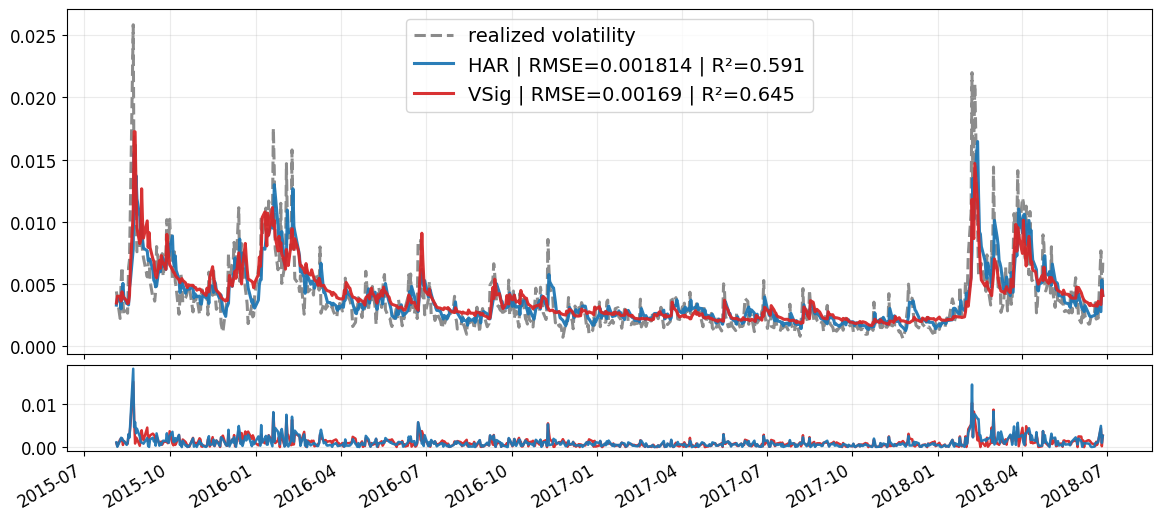

{'slice_stop': 729,
 'transform': 'raw',
 'metrics': {'HAR': {'rmse': 0.0018144478789143702, 'r2': 0.5911561229663548},
  'VSIG': {'rmse': 0.001690011924182236, 'r2': 0.6453107376929041}},
 'title': 'Next-day prediction | split=test | first 729 | p=200'}

In [30]:
plot_compare_predictions_by_depth_jax(
    all_results,
    depth_past=3,
    q=1,
    p=200,
    split="test",
    modes=("HAR", "VSIG"),
    transform="raw",
    title_prefix="Next-day prediction",
    dates=dates_spx_np,
    error_kind="abs",
    date_interval_months=3,
    save_path="SPX_pred_results/frequency_band_jax.pdf",
)

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score


def plot_two_panel_r2fit_and_scatter_jax_style(
    df,                       # summary df for ONE (depth,q) across p
    details,                  # details dict for SAME (depth,q)
    p_scatter: int,
    split_scatter: str = "test",
    p_col="p",
    methods_fit=("SIG", "VSIG"),
    include_har_fit=True,
    har_method="HAR",
    har_last_only=True,
    title_left="R² vs p (linear fits)",
    title_right=None,
    figsize=(15.5, 5.2),
    pad_frac=0.02,
    x_br_ax=1.02,
    x_txt_ax=1.045,
    scatter_n: int = 1500,
    scatter_alpha=0.65,
    scatter_s=10,
    savepath="r2andscatter_SPXVol.pdf",
):
    # -------------------------
    # helpers
    # -------------------------
    def canonical_method(method):
        m = str(method).lower()
        if m in ("normal", "sig", "signature"):
            return "SIG"
        if m == "har":
            return "HAR"
        if m in ("vsig", "volterra", "volterrasig"):
            return "VSIG"
        return str(method)

    def colname(method, split):
        m = canonical_method(method).lower()
        return f"{m}_{split}_r2"

    def style_key(method):
        m = canonical_method(method)
        if m == "SIG":
            return "sig"
        if m == "VSIG":
            return "vsig"
        if m == "HAR":
            return "har"
        return str(method).lower()

    def fit_line(x, y):
        x = np.asarray(x, float)
        y = np.asarray(y, float)
        m = np.isfinite(x) & np.isfinite(y)
        x = x[m]
        y = y[m]
        if len(x) < 2:
            return None
        a, b = np.polyfit(x, y, 1)
        return float(a), float(b)

    def resolve_mode_name(details_dict, wanted: str):
        """
        Return the actual mode string stored in details, matching wanted case-insensitively.
        Works for details keys like ("SIG", p), ("HAR", p), ("VSIG", p).
        """
        wanted_can = canonical_method(wanted).lower()

        for (mode_key, _p) in details_dict.keys():
            if canonical_method(mode_key).lower() == wanted_can:
                return mode_key

        raise KeyError(
            f"Mode '{wanted}' not found in details. "
            f"Available modes: {sorted({m for (m, _) in details_dict.keys()})}"
        )

    def available_ps_for_mode(details_dict, wanted_mode: str):
        m = resolve_mode_name(details_dict, wanted_mode)
        return np.array(
            sorted({int(pp) for (mm, pp) in details_dict.keys() if mm == m}),
            dtype=int,
        )

    def snap_p(details_dict, wanted_mode: str, p_req: int):
        ps = available_ps_for_mode(details_dict, wanted_mode)
        if len(ps) == 0:
            raise KeyError(f"No p values found for mode={wanted_mode}.")

        p_req = int(p_req)
        if p_req in set(ps.tolist()):
            return p_req

        p_sel = int(ps[np.argmin(np.abs(ps - p_req))])
        print(
            f"[plot_two_panel_r2fit_and_scatter] "
            f"p_scatter={p_req} not found for {wanted_mode}; using nearest p={p_sel}."
        )
        return p_sel

    def _get_arrays(mode_wanted, p_val, split):
        mode_key = resolve_mode_name(details, mode_wanted)
        out = details[(mode_key, int(p_val))][split]
        yt = np.asarray(out["y_true"]).ravel()
        yp = np.asarray(out["y_pred"]).ravel()
        return yt, yp

    # -------------------------
    # prep data for left plot
    # -------------------------
    d = df.sort_values(p_col).reset_index(drop=True).copy()
    ps = d[p_col].to_numpy(dtype=float)

    # start left plot at second p value, as in your original code
    if len(d) >= 2:
        d_left = d.iloc[1:].copy()
        ps_left = d_left[p_col].to_numpy(dtype=float)
    else:
        d_left = d
        ps_left = ps

    xmin, xmax = float(np.min(ps_left)), float(np.max(ps_left))
    xgrid = np.array([xmin, xmax], dtype=float)

    style_fit = {
        "sig":  dict(color="r", ls="-",  lw=2.6),
        "vsig": dict(color="b", ls="--", lw=2.6),
        "har":  dict(color="k", ls=":",  lw=2.4),
    }

    # -------------------------
    # figure
    # -------------------------
    fig, (axL, axR) = plt.subplots(1, 2, figsize=figsize)

    # =========================
    # LEFT: linear fits + outside brackets
    # =========================
    bands = {"train": [], "test": []}

    for split in ("train", "test"):
        # SIG / VSIG fits
        for m in methods_fit:
            m_can = canonical_method(m)
            r2_col = colname(m_can, split)

            if r2_col not in d_left.columns:
                print(f"[warning] missing column {r2_col}; skipping.")
                continue

            y = d_left[r2_col].to_numpy(dtype=float)
            fit = fit_line(ps_left, y)

            if fit is None:
                continue

            a, b = fit
            yfit = a * xgrid + b

            sk = style_key(m_can)
            axL.plot(xgrid, yfit, **style_fit[sk])
            bands[split].extend([float(yfit.min()), float(yfit.max())])

        # HAR benchmark line
        if include_har_fit:
            har_col = colname(har_method, split)

            if har_col in d_left.columns and len(d_left) > 0:
                yhar = d_left[har_col].to_numpy(dtype=float)

                if har_last_only:
                    y0 = float(yhar[-4]) if len(yhar) >= 4 else float(yhar[-1])
                    axL.axhline(y0, **style_fit["har"], alpha=0.95)
                    bands[split].append(y0)
                else:
                    fit = fit_line(ps_left, yhar)
                    if fit is not None:
                        a, b = fit
                        yfit = a * xgrid + b
                        axL.plot(xgrid, yfit, **style_fit["har"], alpha=0.95)
                        bands[split].extend([float(yfit.min()), float(yfit.max())])

    handles = [
        plt.Line2D([0], [0], **style_fit["sig"],  label="$\\mathrm{Sig}$"),
        plt.Line2D([0], [0], **style_fit["vsig"], label="$\\mathrm{VSig}$"),
        plt.Line2D([0], [0], **style_fit["har"],  label="$\\mathrm{HAR}$"),
    ]
    axL.legend(handles=handles, frameon=True, fontsize=11, loc="center left")

    # outside brackets in axes coords
    y_min, y_max = axL.get_ylim()
    pad = pad_frac * 1.0

    def y_to_ax(y):
        return (float(y) - y_min) / (y_max - y_min + 1e-18)

    def draw_bracket_outside(ax, y0_data, y1_data, text, color="0.25"):
        y0 = y_to_ax(min(y0_data, y1_data))
        y1 = y_to_ax(max(y0_data, y1_data))
        y0 = max(0.0, y0 - pad)
        y1 = min(1.0, y1 + pad)

        ax.plot(
            [x_br_ax, x_br_ax],
            [y0, y1],
            transform=ax.transAxes,
            color=color,
            lw=2.0,
            clip_on=False,
        )
        cap = 0.015
        ax.plot(
            [x_br_ax - cap, x_br_ax],
            [y0, y0],
            transform=ax.transAxes,
            color=color,
            lw=2.0,
            clip_on=False,
        )
        ax.plot(
            [x_br_ax - cap, x_br_ax],
            [y1, y1],
            transform=ax.transAxes,
            color=color,
            lw=2.0,
            clip_on=False,
        )
        ax.text(
            x_txt_ax,
            0.5 * (y0 + y1),
            text,
            transform=ax.transAxes,
            va="center",
            ha="left",
            fontsize=12,
            fontweight="bold",
            color=color,
            clip_on=False,
        )

    for split in ("train", "test"):
        if len(bands[split]) > 0:
            draw_bracket_outside(
                axL,
                min(bands[split]),
                max(bands[split]),
                split.upper(),
            )

    axL.set_xlabel("p", fontsize=14)
    axL.set_ylabel("R²", fontsize=14)
    axL.grid(True, alpha=0.25)
    axL.tick_params(axis="both", labelsize=12)

    # =========================
    # RIGHT: scatter true vs pred (HAR + VSIG)
    # =========================
    split_scatter = split_scatter.lower()

    if title_right is None:
        title_right = f"True vs Pred ({split_scatter}) | p={int(p_scatter)}"

    # snap p_scatter to available p for both modes
    p_har = snap_p(details, "HAR", p_scatter)
    p_vsig = snap_p(details, "VSIG", p_scatter)

    if p_har != p_vsig:
        print(
            f"[warning] snapped p differs: HAR uses p={p_har}, VSIG uses p={p_vsig}."
        )

    # use the requested/common p if possible
    p_use = p_vsig

    yt_har, yp_har = _get_arrays("HAR", p_har, split_scatter)
    yt_vsig, yp_vsig = _get_arrays("VSIG", p_vsig, split_scatter)

    if len(yt_har) != len(yt_vsig) or not np.allclose(
        yt_har, yt_vsig, rtol=1e-10, atol=1e-12
    ):
        print("[WARN] y_true differs between HAR and VSIG outputs; using HAR y_true for scatter.")

    y_true = yt_har

    if scatter_n is not None and len(y_true) > scatter_n:
        rng = np.random.default_rng(0)
        idx = rng.choice(len(y_true), size=int(scatter_n), replace=False)
        y_true_s = y_true[idx]
        yp_har_s = yp_har[idx]
        yp_vsig_s = yp_vsig[idx]
    else:
        y_true_s = y_true
        yp_har_s = yp_har
        yp_vsig_s = yp_vsig

    mn = float(min(y_true_s.min(), yp_har_s.min(), yp_vsig_s.min()))
    mx = float(max(y_true_s.max(), yp_har_s.max(), yp_vsig_s.max()))

    r2_har = float(r2_score(y_true, yp_har))
    r2_vsig = float(r2_score(y_true, yp_vsig))

    axR.scatter(
        y_true_s,
        yp_har_s,
        s=scatter_s,
        alpha=scatter_alpha,
        color="tab:orange",
        marker="o",
        label=f"HAR (R²={r2_har:.3f})",
    )

    axR.scatter(
        y_true_s,
        yp_vsig_s,
        s=scatter_s,
        alpha=scatter_alpha,
        color="tab:blue",
        marker="x",
        label=f"VSig (R²={r2_vsig:.3f})",
    )

    axR.plot([mn, mx], [mn, mx], color="0.35", lw=1.8, alpha=0.8)
    axR.set_xlim(mn, mx)
    axR.set_ylim(mn, mx)

    axR.set_xlabel("true RV", fontsize=14)
    axR.set_ylabel("predicted RV", fontsize=14)
    axR.grid(True, alpha=0.25)
    axR.tick_params(axis="both", labelsize=11)
    axR.legend(frameon=True, fontsize=14, loc="best")

    fig.subplots_adjust(right=0.95, wspace=0.28)
    plt.tight_layout()

    if savepath is not None:
        plt.savefig(savepath, format="pdf", bbox_inches="tight")

    plt.savefig("r2andscatter.pdf", bbox_inches="tight", dpi=300)
    plt.show()

    return None

def plot_rmse_r2_for_setting_jax(
    df_summary_all,
    all_results,
    depth_past,
    q,
    p_scatter=None,
    split_scatter="test",
    p_col="p",
    savepath="r2andscatter_SPXVol.pdf",
):
    depth_past = int(depth_past)
    q = int(q)

    d = df_summary_all[
        (df_summary_all["depth_past"].astype(int) == depth_past) &
        (df_summary_all["q"].astype(int) == q)
    ].copy()

    if d.empty:
        raise ValueError(f"No rows found for depth_past={depth_past}, q={q}.")

    d = d.sort_values(p_col).reset_index(drop=True)

    key = (depth_past, q)

    if key not in all_results:
        candidates = [
            k for k in all_results.keys()
            if isinstance(k, tuple)
            and len(k) >= 2
            and int(k[0]) == depth_past
            and int(k[1]) == q
        ]

        if len(candidates) == 0:
            raise KeyError(
                f"all_results has no entry for key={key}. "
                f"Example keys: {list(all_results.keys())[:10]}"
            )

        key = candidates[0]

    details = all_results[key]["details"]

    ps_avail = d[p_col].astype(int).to_numpy()

    if p_scatter is None:
        p_scatter = int(ps_avail[-1])
    else:
        p_scatter = int(p_scatter)

    return plot_two_panel_r2fit_and_scatter_jax_style(
        df=d,
        details=details,
        p_scatter=p_scatter,
        split_scatter=split_scatter,
        p_col=p_col,
        methods_fit=("SIG", "VSIG"),
        include_har_fit=True,
        har_method="HAR",
        har_last_only=True,
        savepath=savepath,
    )

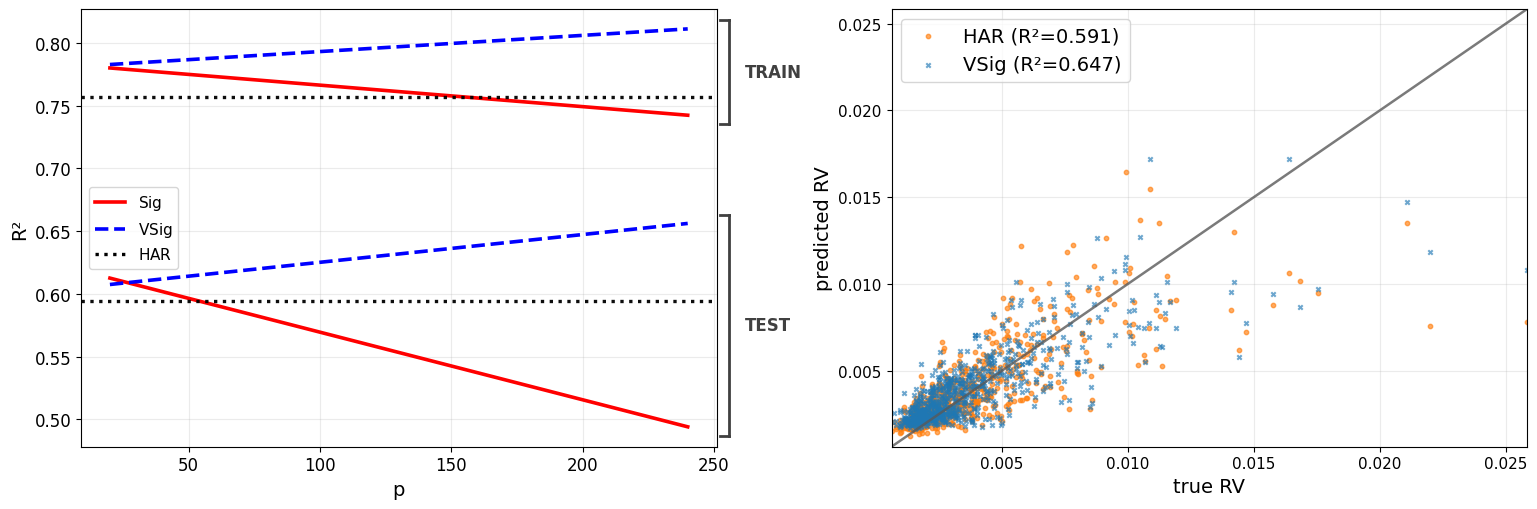

In [21]:
plot_rmse_r2_for_setting_jax(
    df_summary_all=df_summary_all,
    all_results=all_results,
    depth_past=3,
    q=1,
    p_scatter=200,
    split_scatter="test",
    savepath="SPX_pred_results/r2andscatter_depth3_q1_p200.pdf",
)

## Table with coefficient of determination

In [32]:
import numpy as np
import pandas as pd

def make_big_table_q_by_p_triples_plus_params_jax(
    df_summary_all: pd.DataFrame,
    split: str = "test",
    p_values=None,
    n_p: int = 6,
    params_from_p: int = None,
    reduce_depth: str = "best_vsig_r2",
    digits_r2: int = 3,
    digits_param: int = 6,
    depth_past: int = None,
    p_start_idx: int = 0,
    include_c: bool = True,
):
    """
    New JAX result table.

    Output:
        index: q
        columns: selected p-values plus parameter columns.

    Each p-column entry is:

        R2SIG/R2VSIG/R2HAR

    Requires columns:
        q, p, depth_past
        sig_{split}_r2, vsig_{split}_r2, har_{split}_r2
        vsig_best_lambda1, vsig_best_lambda2,
        vsig_best_alpha1, vsig_best_alpha2,
        optionally vsig_best_c
    """

    split = str(split).lower()
    if split not in ("train", "val", "test"):
        raise ValueError("split must be 'train', 'val', or 'test'")

    sig_r2_col = f"sig_{split}_r2"
    vsig_r2_col = f"vsig_{split}_r2"
    har_r2_col = f"har_{split}_r2"

    lam1_col = "vsig_best_lambda1"
    lam2_col = "vsig_best_lambda2"
    a1_col = "vsig_best_alpha1"
    a2_col = "vsig_best_alpha2"
    c_col = "vsig_best_c"

    need = {
        "q", "p",
        sig_r2_col, vsig_r2_col, har_r2_col,
        lam1_col, lam2_col, a1_col, a2_col,
    }

    if include_c:
        need.add(c_col)

    missing = need - set(df_summary_all.columns)
    if missing:
        raise KeyError(f"Missing columns in df_summary_all: {sorted(missing)}")

    d = df_summary_all.copy()
    d["q"] = d["q"].astype(int)
    d["p"] = d["p"].astype(int)

    # Optional fixed depth.
    if depth_past is not None:
        if "depth_past" not in d.columns:
            raise KeyError("depth_past was provided, but df_summary_all has no 'depth_past' column.")

        d["depth_past"] = d["depth_past"].astype(int)
        depth_past = int(depth_past)

        d = d[d["depth_past"] == depth_past].copy()

        if d.empty:
            avail = sorted(
                df_summary_all["depth_past"].dropna().astype(int).unique().tolist()
            )
            raise ValueError(
                f"No rows for depth_past={depth_past}. "
                f"Available depth_past values: {avail}"
            )

        reduce_depth = None

    # Choose p-list.
    ps_avail = np.array(sorted(d["p"].unique()), dtype=int)
    if len(ps_avail) == 0:
        raise ValueError("No p values available.")

    if p_values is None:
        p_start_idx = int(p_start_idx)

        if p_start_idx < 0:
            raise ValueError("p_start_idx must be >= 0")

        if p_start_idx >= len(ps_avail):
            raise ValueError(
                f"p_start_idx={p_start_idx} is too large; "
                f"only {len(ps_avail)} p values available."
            )

        ps_avail2 = ps_avail[p_start_idx:]

        if len(ps_avail2) <= int(n_p):
            p_sel = ps_avail2.tolist()
        else:
            idx = np.linspace(0, len(ps_avail2) - 1, int(n_p)).round().astype(int)
            p_sel = ps_avail2[np.unique(idx)].tolist()

    else:
        p_sel = []
        ps_set = set(ps_avail.tolist())

        for pp in list(p_values):
            pp = int(pp)
            if pp in ps_set:
                p_sel.append(pp)
            else:
                p_sel.append(int(ps_avail[np.argmin(np.abs(ps_avail - pp))]))

        p_sel = sorted(set(p_sel))

    d = d[d["p"].isin(p_sel)].copy()

    if d.empty:
        raise ValueError("No rows left after filtering to selected p values.")

    # If depth is not fixed, reduce one row per (q,p).
    if reduce_depth is not None and "depth_past" in d.columns:
        if reduce_depth == "best_vsig_r2":

            def pick_best(g):
                vals = pd.to_numeric(g[vsig_r2_col], errors="coerce")
                if vals.notna().any():
                    return g.loc[vals.idxmax()]
                return g.iloc[0]

            d = d.groupby(["q", "p"], as_index=False).apply(pick_best)

            if isinstance(d.index, pd.MultiIndex):
                d = d.reset_index(drop=True)

        elif reduce_depth == "first":
            d = (
                d.sort_values(["q", "p", "depth_past"])
                 .groupby(["q", "p"], as_index=False)
                 .head(1)
                 .copy()
            )

        else:
            raise ValueError("reduce_depth must be 'best_vsig_r2', 'first', or None")

    # Which p to take parameters from.
    if params_from_p is None:
        p_params = int(p_sel[-1])
    else:
        params_from_p = int(params_from_p)

        if params_from_p not in set(p_sel):
            p_params = int(np.array(p_sel)[np.argmin(np.abs(np.array(p_sel) - params_from_p))])
            print(
                f"[make_big_table] params_from_p={params_from_p} not in selected p; "
                f"using nearest {p_params}."
            )
        else:
            p_params = params_from_p

    def _fmt_r2(x):
        try:
            x = float(x)
            if not np.isfinite(x):
                return ""
            return f"{x:.{digits_r2}f}"
        except Exception:
            return ""

    def _fmt_param(x):
        try:
            x = float(x)
            if not np.isfinite(x):
                return ""
            return f"{x:.{digits_param}g}"
        except Exception:
            return ""

    out_rows = []

    for q in sorted(d["q"].unique()):
        row = {"q": int(q)}
        dq = d[d["q"] == int(q)]

        # p-columns: Sig/VSig/HAR R² triples.
        for p in p_sel:
            dp = dq[dq["p"] == int(p)]

            if dp.empty:
                row[int(p)] = ""
                continue

            r = dp.iloc[0]

            r2_sig = _fmt_r2(r[sig_r2_col])
            r2_vsig = _fmt_r2(r[vsig_r2_col])
            r2_har = _fmt_r2(r[har_r2_col])

            row[int(p)] = f"{r2_sig}/{r2_vsig}/{r2_har}"

        # Parameter columns from p_params.
        dp0 = dq[dq["p"] == int(p_params)]

        if dp0.empty:
            row["lambda1"] = ""
            row["lambda2"] = ""
            row["alpha1"] = ""
            row["alpha2"] = ""
            if include_c:
                row["c"] = ""
        else:
            r0 = dp0.iloc[0]

            row["lambda1"] = _fmt_param(r0[lam1_col])
            row["lambda2"] = _fmt_param(r0[lam2_col])
            row["alpha1"] = _fmt_param(r0[a1_col])
            row["alpha2"] = _fmt_param(r0[a2_col])

            if include_c:
                row["c"] = _fmt_param(r0[c_col])

        out_rows.append(row)

    out = pd.DataFrame(out_rows).set_index("q")

    param_cols = ["lambda1", "lambda2", "alpha1", "alpha2"]
    if include_c:
        param_cols.append("c")

    out = out[[*p_sel, *param_cols]]
    out.index.name = "q"

    return out

In [33]:
tbl = make_big_table_q_by_p_triples_plus_params_jax(
    df_summary_all,
    split="test",
    depth_past=3,
    n_p=6,
    p_start_idx=1,
    include_c=True,
)

display(tbl)

,20,60,110,150,200,240,lambda1,lambda2,alpha1,alpha2,c
q,,,,,,,,,,,
1,0.592/0.595/0.576,0.580/0.616/0.581,0.568/0.626/0.585,0.562/0.635/0.589,0.520/0.645/0.591,0.469/0.652/0.605,39.3599,0.0314193,0.0104713,20.5194,-1.50498
3,0.339/0.343/0.345,0.375/0.368/0.358,0.376/0.383/0.368,0.385/0.393/0.371,0.355/0.399/0.378,0.345/0.419/0.393,24.7453,0.0247656,0.173117,0.0104349,1.9658
5,0.222/0.212/0.210,0.268/0.245/0.228,0.291/0.258/0.240,0.307/0.268/0.242,0.275/0.276/0.249,0.268/0.289/0.260,14.139,0.129427,0.424466,0.0332166,-0.693118


In [34]:
import re
import numpy as np

def bold_best_triple_cell(cell):
    """
    Takes a cell like '0.123/0.456/0.321'
    and returns '0.123/\\textbf{0.456}/0.321'.
    """
    if not isinstance(cell, str) or "/" not in cell:
        return cell

    parts = cell.split("/")
    if len(parts) != 3:
        return cell

    vals = []
    for p in parts:
        try:
            vals.append(float(re.sub(r"\\textbf\{|\}", "", p)))
        except Exception:
            vals.append(np.nan)

    if not np.isfinite(vals).any():
        return cell

    best = int(np.nanargmax(vals))

    out = []
    for i, p in enumerate(parts):
        if i == best:
            out.append(r"\textbf{" + p + "}")
        else:
            out.append(p)

    return "/".join(out)


def bold_best_triples_in_table(tbl):
    out = tbl.copy()

    # Only apply to p-columns, i.e. columns whose names are integers or digit strings.
    for col in out.columns:
        is_p_col = isinstance(col, (int, np.integer)) or str(col).isdigit()
        if is_p_col:
            out[col] = out[col].map(bold_best_triple_cell)

    return out

In [26]:
tbl_latex = bold_best_triples_in_table(tbl)

print(
    tbl_latex.to_latex(
        escape=False,
        column_format="c" + "c" * len(tbl_latex.columns),
    )
)

\begin{tabular}{cccccccccccc}
\toprule
 & 20 & 60 & 110 & 150 & 200 & 240 & lambda1 & lambda2 & alpha1 & alpha2 & c \\
q &  &  &  &  &  &  &  &  &  &  &  \\
\midrule
1 & 0.592/\textbf{0.595}/0.576 & 0.580/\textbf{0.615}/0.581 & 0.568/\textbf{0.627}/0.585 & 0.562/\textbf{0.636}/0.589 & 0.520/\textbf{0.647}/0.591 & 0.469/\textbf{0.653}/0.605 & 23.1412 & 0.0777959 & 0.0109431 & 14.5366 & 0.405188 \\
3 & 0.339/0.334/\textbf{0.345} & 0.375/\textbf{0.380}/0.358 & 0.376/\textbf{0.386}/0.368 & 0.385/\textbf{0.397}/0.371 & 0.355/\textbf{0.404}/0.378 & 0.345/\textbf{0.422}/0.393 & 12.5935 & 0.0601538 & 0.796449 & 0.234445 & 1.16698 \\
5 & \textbf{0.222}/0.205/0.210 & \textbf{0.268}/0.239/0.228 & \textbf{0.291}/0.245/0.240 & \textbf{0.307}/0.253/0.242 & \textbf{0.275}/0.264/0.249 & 0.268/\textbf{0.280}/0.260 & 26.8907 & 0.243442 & 6.40878 & 0.065183 & 0.133704 \\
\bottomrule
\end{tabular}

